Try some different scaling methods

Code with standardisation waarin Wiener VS Original wordt vergeleken (zie formules in word document)

RUN_ORIGINAL = True
RUN_WIENER = True

===== Running wiener =====
Feature sensitivity table saved to: C:\Users\marti\Documents\Technical Medicine Master\Stages TM2\TM2-3\Technische opdracht\feature_sensitivity_table_original_based_scaling_wiener.csv

                  Intensity  Gaussian noise  Pink noise  Low-pass filter
F0 Mean            0.003491        0.031695    0.050646         0.008613
F0 20th%           0.003889        0.055811    0.093193         0.015563
F0 50th%           0.003642        0.020201    0.027917         0.012668
F0 80th%           0.001011        0.009919    0.014202         0.002692
F0 StdDev          0.016553        0.145646    0.238537         0.035281
F1 Mean            0.041909        0.160459    0.202259         0.093105
F1 StdDev          0.046679        0.184091    0.223199         0.099867
F2 Mean            0.038842        0.155577    0.184460         0.089319
F2 StdDev          0.061058        0.245382    0.271766         0.132314
F3 Mean            

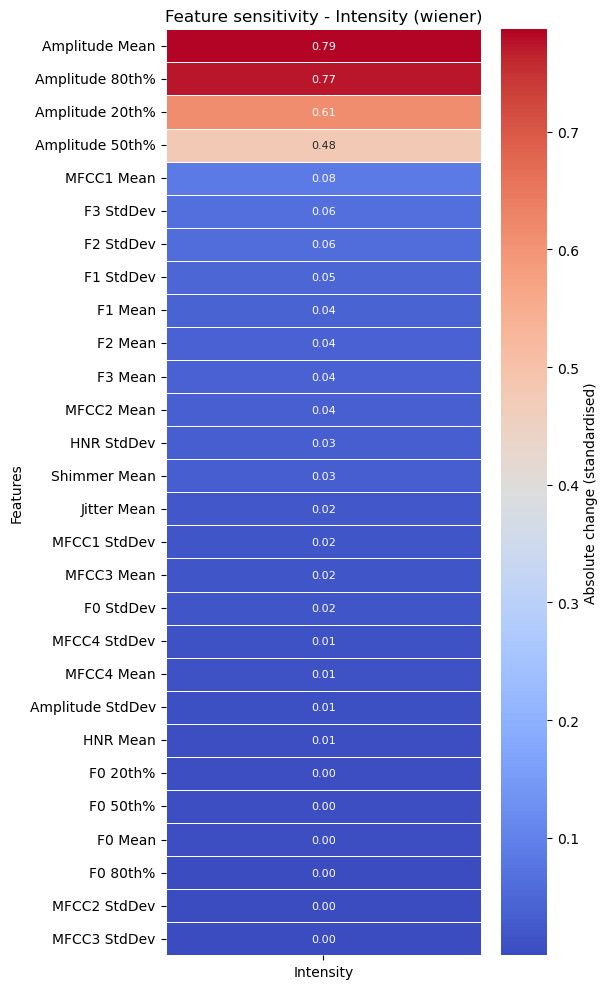

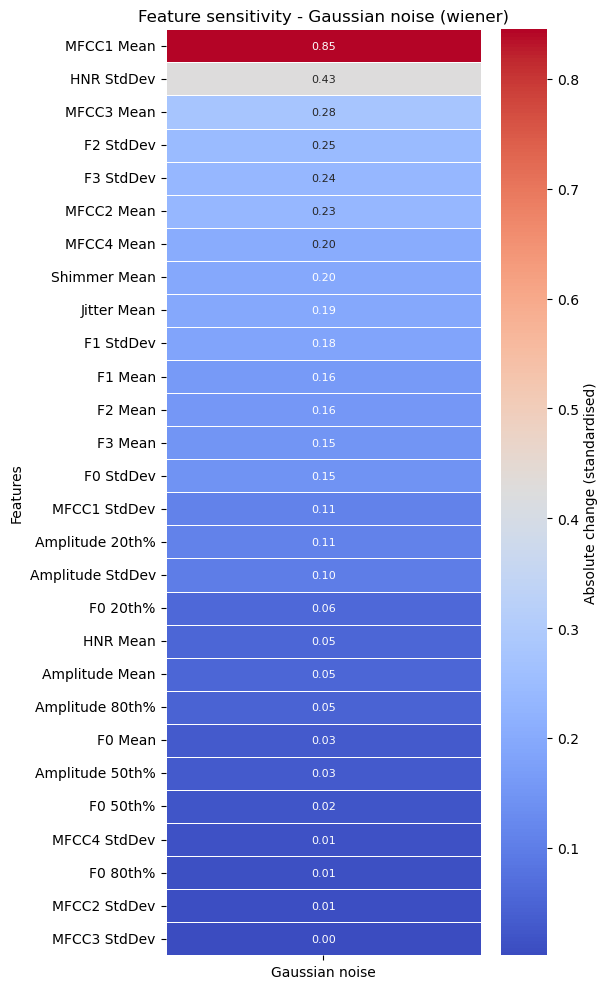

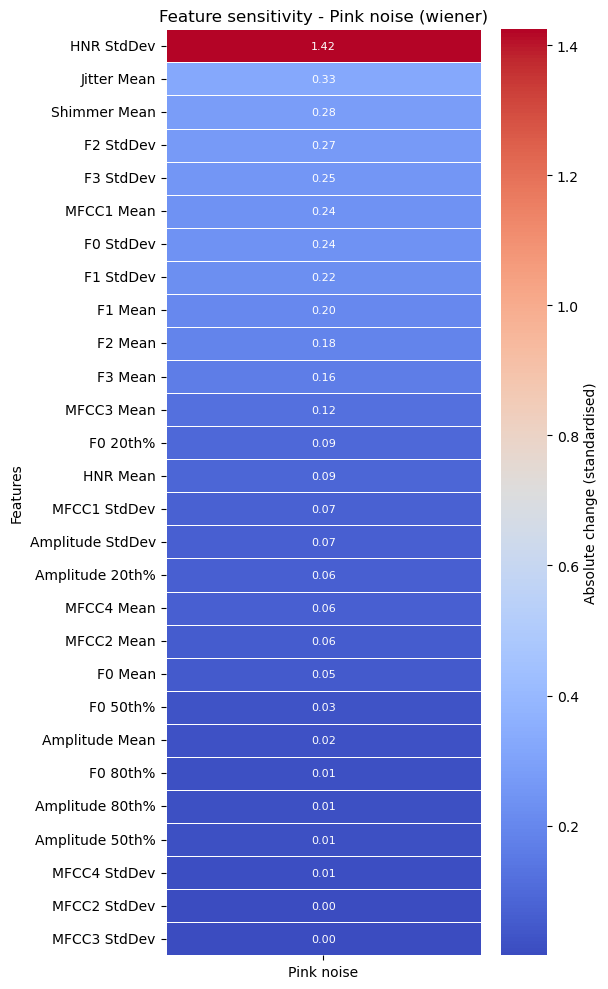

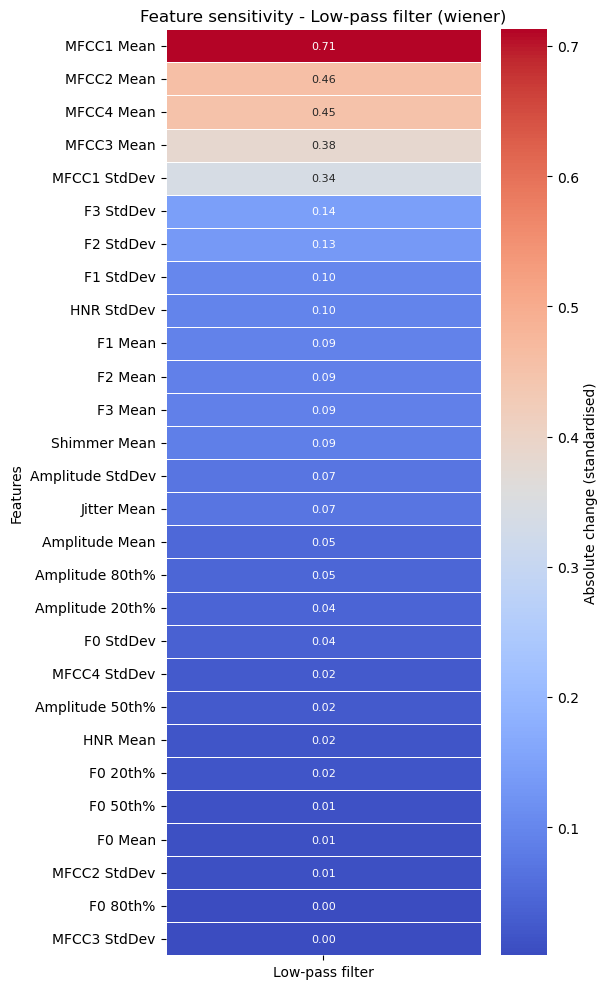

===== Running original =====
Feature sensitivity table saved to: C:\Users\marti\Documents\Technical Medicine Master\Stages TM2\TM2-3\Technische opdracht\feature_sensitivity_table_original_based_scaling_original.csv

                  Intensity  Gaussian noise  Pink noise  Low-pass filter
F0 Mean            0.001181        0.037476    0.027834         0.009083
F0 20th%           0.001749        0.045677    0.035049         0.014393
F0 50th%           0.000481        0.014131    0.010857         0.005286
F0 80th%           0.000349        0.011528    0.010034         0.006380
F0 StdDev          0.007007        0.207289    0.154354         0.040693
F1 Mean            0.020105        0.183073    0.147687         0.087356
F1 StdDev          0.027381        0.227760    0.199590         0.110226
F2 Mean            0.022506        0.199276    0.160970         0.088201
F2 StdDev          0.037443        0.318577    0.275042         0.138846
F3 Mean            0.020398        0.234280    0.17193

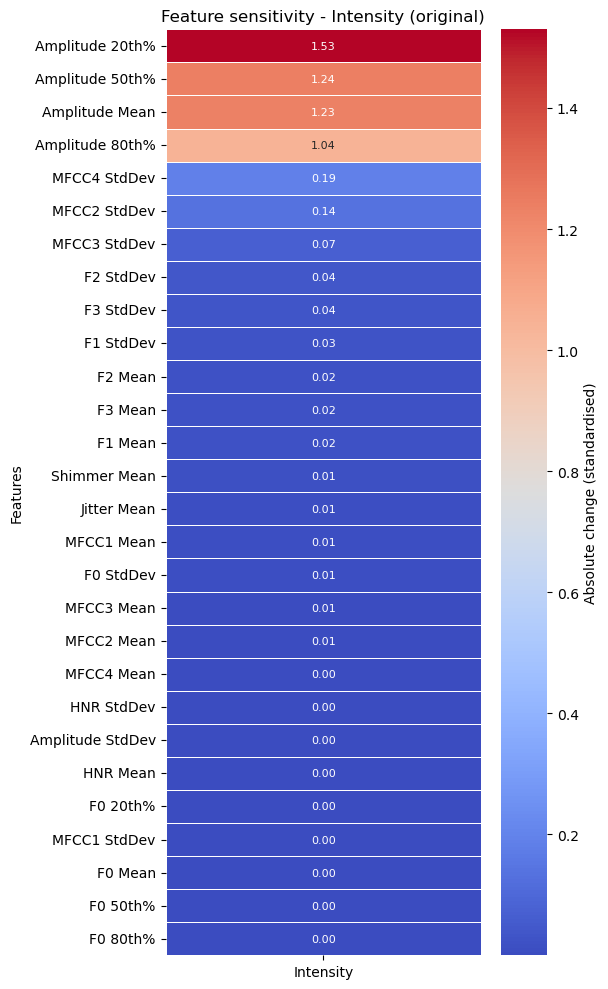

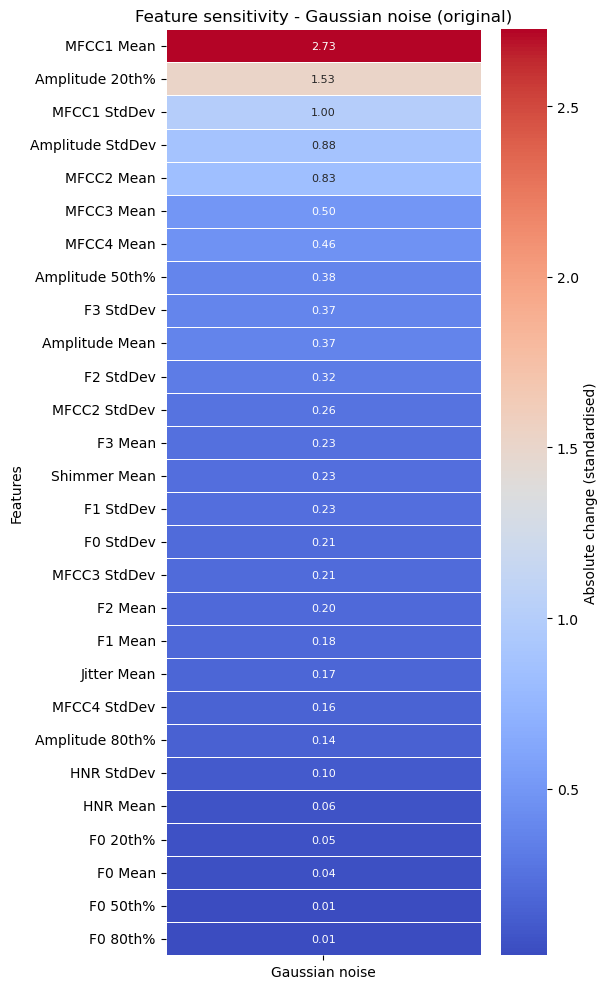

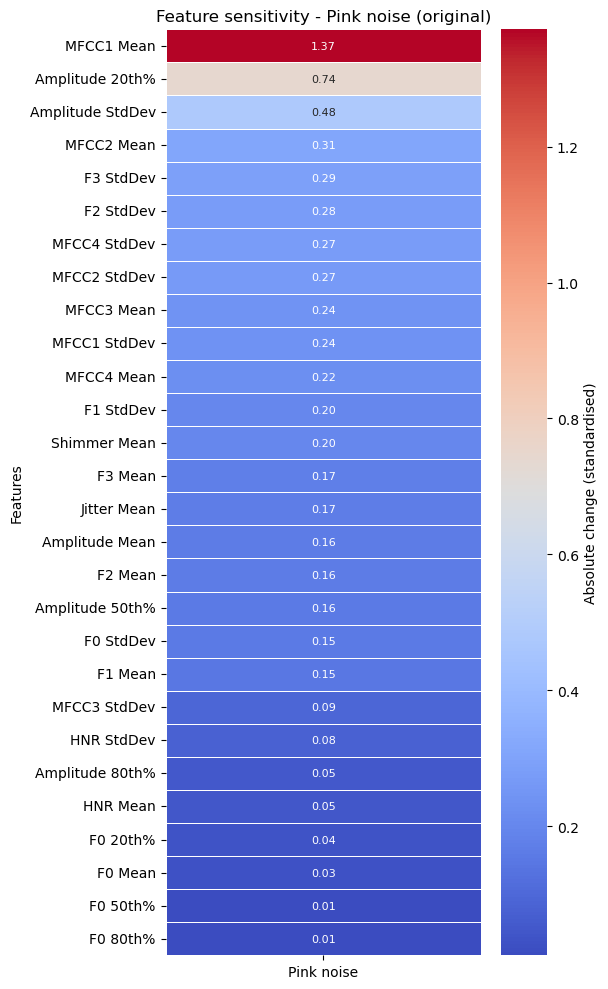

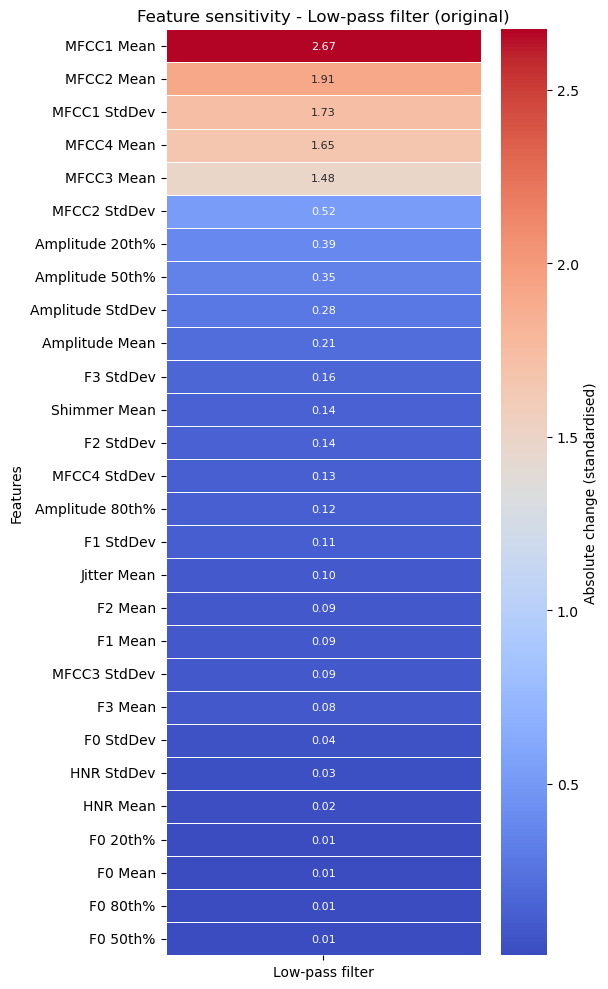

Comparison table saved to: C:\Users\marti\Documents\Technical Medicine Master\Stages TM2\TM2-3\Technische opdracht\feature_sensitivity_comparison_original_vs_wiener.csv

                  Intensity  Gaussian noise  Pink noise  Low-pass filter
F0 Mean            0.002310       -0.005781    0.022812        -0.000470
F0 20th%           0.002141        0.010133    0.058144         0.001170
F0 50th%           0.003160        0.006070    0.017060         0.007381
F0 80th%           0.000662       -0.001609    0.004169        -0.003688
F0 StdDev          0.009546       -0.061642    0.084183        -0.005412
F1 Mean            0.021804       -0.022614    0.054571         0.005749
F1 StdDev          0.019298       -0.043668    0.023609        -0.010358
F2 Mean            0.016337       -0.043699    0.023490         0.001118
F2 StdDev          0.023615       -0.073195   -0.003276        -0.006532
F3 Mean            0.016810       -0.084922   -0.007116         0.004521
F3 StdDev          0.027811

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler

# =========================
# Paths + settings
# =========================
BASE_PATH = Path(r"C:\Users\marti\Documents\Technical Medicine Master\Stages TM2\TM2-3\Technische opdracht")

RUN_ORIGINAL = True
RUN_WIENER = True

OUTPUT_FILES = {
    "original": BASE_PATH / "feature_sensitivity_table_original_based_scaling_original.csv",
    "wiener": BASE_PATH / "feature_sensitivity_table_original_based_scaling_wiener.csv",
}

HEATMAP_DIR = BASE_PATH / "heatmaps_per_perturbation_original_based_scaling"
HEATMAP_DIR.mkdir(parents=True, exist_ok=True)

# Optional: direct comparison table between original and wiener
SAVE_COMPARISON_TABLE = True
COMPARISON_OUTPUT_FILE = BASE_PATH / "feature_sensitivity_comparison_original_vs_wiener.csv"

# =========================
# Selected features
# =========================
selected_features = {
    "F0 Mean": "F0semitoneFrom27.5Hz_sma3nz_amean",
    "F0 20th%": "F0semitoneFrom27.5Hz_sma3nz_percentile20.0",
    "F0 50th%": "F0semitoneFrom27.5Hz_sma3nz_percentile50.0",
    "F0 80th%": "F0semitoneFrom27.5Hz_sma3nz_percentile80.0",
    "F0 StdDev": "F0semitoneFrom27.5Hz_sma3nz_stddevNorm",
    "F1 Mean": "F1frequency_sma3nz_amean",
    "F1 StdDev": "F1frequency_sma3nz_stddevNorm",
    "F2 Mean": "F2frequency_sma3nz_amean",
    "F2 StdDev": "F2frequency_sma3nz_stddevNorm",
    "F3 Mean": "F3frequency_sma3nz_amean",
    "F3 StdDev": "F3frequency_sma3nz_stddevNorm",
    "HNR Mean": "HNRdBACF_sma3nz_amean",
    "HNR StdDev": "HNRdBACF_sma3nz_stddevNorm",
    "Jitter Mean": "jitterLocal_sma3nz_amean",
    "Amplitude Mean": "loudness_sma3_amean",
    "Amplitude 20th%": "loudness_sma3_percentile20.0",
    "Amplitude 50th%": "loudness_sma3_percentile50.0",
    "Amplitude 80th%": "loudness_sma3_percentile80.0",
    "Amplitude StdDev": "loudness_sma3_stddevNorm",
    "MFCC1 Mean": "mfcc1_sma3_amean",
    "MFCC1 StdDev": "mfcc1_sma3_stddevNorm",
    "MFCC2 Mean": "mfcc2_sma3_amean",
    "MFCC2 StdDev": "mfcc2_sma3_stddevNorm",
    "MFCC3 Mean": "mfcc3_sma3_amean",
    "MFCC3 StdDev": "mfcc3_sma3_stddevNorm",
    "MFCC4 Mean": "mfcc4_sma3_amean",
    "MFCC4 StdDev": "mfcc4_sma3_stddevNorm",
    "Shimmer Mean": "shimmerLocaldB_sma3nz_amean",
}

# =========================
# Perturbations
# =========================
PERTURBATION_GROUPS = {}

if RUN_WIENER:
    PERTURBATION_GROUPS["wiener"] = {
        "Intensity": {
            "original": BASE_PATH / "opensmile_wiener_pain.csv",
            "-6": BASE_PATH / "opensmile_wiener_intensity_-6dB_pain.csv",
            "-3": BASE_PATH / "opensmile_wiener_intensity_-3dB_pain.csv",
            "+3": BASE_PATH / "opensmile_wiener_intensity_3dB_pain.csv",
            "+6": BASE_PATH / "opensmile_wiener_intensity_6dB_pain.csv",
        },
        "Gaussian noise": {
            "original": BASE_PATH / "opensmile_wiener_pain.csv",
            "0.5": BASE_PATH / "opensmile_wiener_gaussian_low_pain.csv",
            "2": BASE_PATH / "opensmile_wiener_gaussian_medium_pain.csv",
            "5": BASE_PATH / "opensmile_wiener_gaussian_high_pain.csv",
            "10": BASE_PATH / "opensmile_wiener_gaussian_very_high_pain.csv",
        },
        "Pink noise": {
            "original": BASE_PATH / "opensmile_wiener_pain.csv",
            "0.5": BASE_PATH / "opensmile_wiener_pink_low_pain.csv",
            "2": BASE_PATH / "opensmile_wiener_pink_medium_pain.csv",
            "5": BASE_PATH / "opensmile_wiener_pink_high_pain.csv",
            "10": BASE_PATH / "opensmile_wiener_pink_very_high_pain.csv",
        },
        "Low-pass filter": {
            "original": BASE_PATH / "opensmile_wiener_pain.csv",
            "6000": BASE_PATH / "opensmile_wiener_lowpass_low_pain.csv",
            "5000": BASE_PATH / "opensmile_wiener_lowpass_medium_pain.csv",
            "4000": BASE_PATH / "opensmile_wiener_lowpass_high_pain.csv",
            "3000": BASE_PATH / "opensmile_wiener_lowpass_very_high_pain.csv",
        },
    }

if RUN_ORIGINAL:
    PERTURBATION_GROUPS["original"] = {
        "Intensity": {
            "original": BASE_PATH / "opensmile_original_pain.csv",
            "-6": BASE_PATH / "opensmile_original_intensity_-6dB_pain.csv",
            "-3": BASE_PATH / "opensmile_original_intensity_-3dB_pain.csv",
            "+3": BASE_PATH / "opensmile_original_intensity_3dB_pain.csv",
            "+6": BASE_PATH / "opensmile_original_intensity_6dB_pain.csv",
        },
        "Gaussian noise": {
            "original": BASE_PATH / "opensmile_original_pain.csv",
            "0.5": BASE_PATH / "opensmile_original_gaussian_low_pain.csv",
            "2": BASE_PATH / "opensmile_original_gaussian_medium_pain.csv",
            "5": BASE_PATH / "opensmile_original_gaussian_high_pain.csv",
            "10": BASE_PATH / "opensmile_original_gaussian_very_high_pain.csv",
        },
        "Pink noise": {
            "original": BASE_PATH / "opensmile_original_pain.csv",
            "0.5": BASE_PATH / "opensmile_original_pink_low_pain.csv",
            "2": BASE_PATH / "opensmile_original_pink_medium_pain.csv",
            "5": BASE_PATH / "opensmile_original_pink_high_pain.csv",
            "10": BASE_PATH / "opensmile_original_pink_very_high_pain.csv",
        },
        "Low-pass filter": {
            "original": BASE_PATH / "opensmile_original_pain.csv",
            "6000": BASE_PATH / "opensmile_original_lowpass_low_pain.csv",
            "5000": BASE_PATH / "opensmile_original_lowpass_medium_pain.csv",
            "4000": BASE_PATH / "opensmile_original_lowpass_high_pain.csv",
            "3000": BASE_PATH / "opensmile_original_lowpass_very_high_pain.csv",
        },
    }

if not PERTURBATION_GROUPS:
    raise ValueError("Set RUN_ORIGINAL and/or RUN_WIENER to True.")

# =========================
# Functions
# =========================
def load_and_sort_csv(file_path):
    df = pd.read_csv(file_path)
    return df.sort_values(by=["participant_id", "filename"]).reset_index(drop=True)


def check_alignment(reference_df, comparison_df, label):
    ref_ids = reference_df[["participant_id", "filename"]]
    cmp_ids = comparison_df[["participant_id", "filename"]]

    if not ref_ids.equals(cmp_ids):
        raise ValueError(f"Mismatch in rows for {label}")


def fit_shared_scaler_on_original_clean(base_path, feature_cols):
    """
    Fit ONE shared scaler on the clean original dataset only.
    This provides:
        mu_original_clean and sigma_original_clean
    for every selected feature.
    """
    original_clean_path = base_path / "opensmile_original_pain.csv"
    original_clean_df = load_and_sort_csv(original_clean_path)

    missing_features = [
        feature_col for feature_col in feature_cols
        if feature_col not in original_clean_df.columns
    ]
    if missing_features:
        raise ValueError(
            f"These features are missing from the original clean CSV: {missing_features}"
        )

    scaler = StandardScaler()
    scaler.fit(original_clean_df[feature_cols])
    return scaler


def run_sensitivity_analysis(dataset_name, perturbation_groups, output_file, shared_scaler):
    """
    Calculate feature sensitivity per perturbation group for one dataset.

    Scaling:
    - ONE shared scaler fitted on opensmile_original_pain.csv
    - applied to everything:
        * original clean
        * original perturbations
        * wiener clean
        * wiener perturbations

    Absolute difference is then computed WITHIN each dataset:
    - original: |x'_original_clean - x'_original_perturbation|
    - wiener:   |x'_wiener_clean  - x'_wiener_perturbation|
    """
    all_data = {}

    # Load all CSV files
    for group_name, files in perturbation_groups.items():
        all_data[group_name] = {}
        for level_label, file_path in files.items():
            all_data[group_name][level_label] = load_and_sort_csv(file_path)

    # Check row alignment within each perturbation group
    for group_name, dfs in all_data.items():
        clean_df = dfs["original"]
        for level_label, df in dfs.items():
            if level_label == "original":
                continue
            check_alignment(clean_df, df, f"{dataset_name} - {group_name} - {level_label}")

    feature_cols = list(selected_features.values())

    # Check if required features are present
    for group_name, dfs in all_data.items():
        clean_df = dfs["original"]
        missing_features = [
            feature_col for feature_col in feature_cols
            if feature_col not in clean_df.columns
        ]
        if missing_features:
            raise ValueError(
                f"These features are missing from the CSV files for {dataset_name} - {group_name}: {missing_features}"
            )

    # Results table
    results = pd.DataFrame(
        index=selected_features.keys(),
        columns=perturbation_groups.keys(),
        dtype=float
    )

    # Process each perturbation group
    for group_name, dfs in all_data.items():
        clean_df = dfs["original"]

        # Scale clean data using shared scaler fitted on original clean
        clean_std = shared_scaler.transform(clean_df[feature_cols])

        for i, (feature_name, feature_col) in enumerate(selected_features.items()):
            level_scores = []

            for level_label, df in dfs.items():
                if level_label == "original":
                    continue

                # Scale perturbed data using same shared scaler
                perturbed_std = shared_scaler.transform(df[feature_cols])

                # Absolute difference WITHIN dataset
                abs_diff = np.abs(clean_std[:, i] - perturbed_std[:, i])

                # Average over files for this perturbation level
                level_scores.append(abs_diff.mean())

            # Average over perturbation levels within group
            results.loc[feature_name, group_name] = np.mean(level_scores)

    results.to_csv(output_file)

    print(f"Feature sensitivity table saved to: {output_file}")
    print()
    print(results)
    print()

    return results


def save_heatmaps(results_df, dataset_name, heatmap_dir):
    dataset_heatmap_dir = heatmap_dir / dataset_name
    dataset_heatmap_dir.mkdir(parents=True, exist_ok=True)

    for group_name in results_df.columns:
        heatmap_data = results_df[[group_name]].copy()
        heatmap_data = heatmap_data.sort_values(by=group_name, ascending=False)

        plt.figure(figsize=(6, 10))
        sns.heatmap(
            heatmap_data,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            cbar_kws={"label": "Absolute change (standardised)"},
            linewidths=0.5,
            cbar=True,
            annot_kws={"size": 8}
        )

        plt.title(f"Feature sensitivity - {group_name} ({dataset_name})")
        plt.xlabel("")
        plt.ylabel("Features")
        plt.tight_layout()

        plt.savefig(
            dataset_heatmap_dir / f"heatmap_{group_name.replace(' ', '_')}_{dataset_name}.png",
            dpi=300
        )
        plt.show()
        plt.close()


def save_original_vs_wiener_comparison(all_results, output_file):
    """
    Save a direct comparison table:
    difference = wiener - original
    """
    if "original" not in all_results or "wiener" not in all_results:
        return

    comparison_df = all_results["wiener"] - all_results["original"]
    comparison_df.to_csv(output_file)

    print(f"Comparison table saved to: {output_file}")
    print()
    print(comparison_df)
    print()


# =========================
# Run
# =========================
all_results = {}

print("RUN_ORIGINAL =", RUN_ORIGINAL)
print("RUN_WIENER =", RUN_WIENER)
print()

feature_cols = list(selected_features.values())

# ONE shared scaler based only on clean original data
shared_scaler = fit_shared_scaler_on_original_clean(BASE_PATH, feature_cols)

for dataset_name, perturbation_groups in PERTURBATION_GROUPS.items():
    print(f"===== Running {dataset_name} =====")

    results = run_sensitivity_analysis(
        dataset_name=dataset_name,
        perturbation_groups=perturbation_groups,
        output_file=OUTPUT_FILES[dataset_name],
        shared_scaler=shared_scaler
    )

    all_results[dataset_name] = results
    save_heatmaps(results, dataset_name, HEATMAP_DIR)

if SAVE_COMPARISON_TABLE:
    save_original_vs_wiener_comparison(all_results, COMPARISON_OUTPUT_FILE)

Kijken of er wat anders uitkomt als je niet speciaal voor Wiener vs Original had gedaan

RUN_ORIGINAL = True
RUN_WIENER = True

===== Running wiener =====
Feature sensitivity table saved to: C:\Users\marti\Documents\Technical Medicine Master\Stages TM2\TM2-3\Technische opdracht\feature_sensitivity_table_dataset_based_scaling_wiener.csv
                  Intensity  Gaussian noise  Pink noise  Low-pass filter
F0 Mean            0.003691        0.033516    0.053555         0.009108
F0 20th%           0.003283        0.047101    0.078650         0.013134
F0 50th%           0.003429        0.019020    0.026286         0.011927
F0 80th%           0.001005        0.009856    0.014112         0.002675
F0 StdDev          0.008611        0.075764    0.124085         0.018353
F1 Mean            0.043576        0.166843    0.210306         0.096809
F1 StdDev          0.055891        0.220418    0.267244         0.119574
F2 Mean            0.043030        0.172352    0.204350         0.098949
F2 StdDev          0.068027        0.273388    0.302784         0.147416
F3 Mean            0.

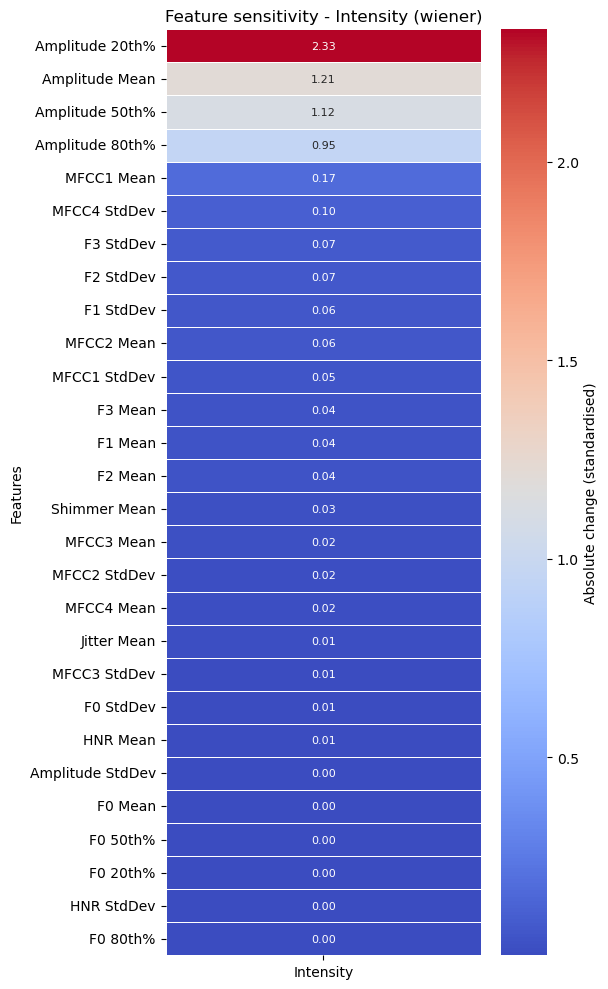

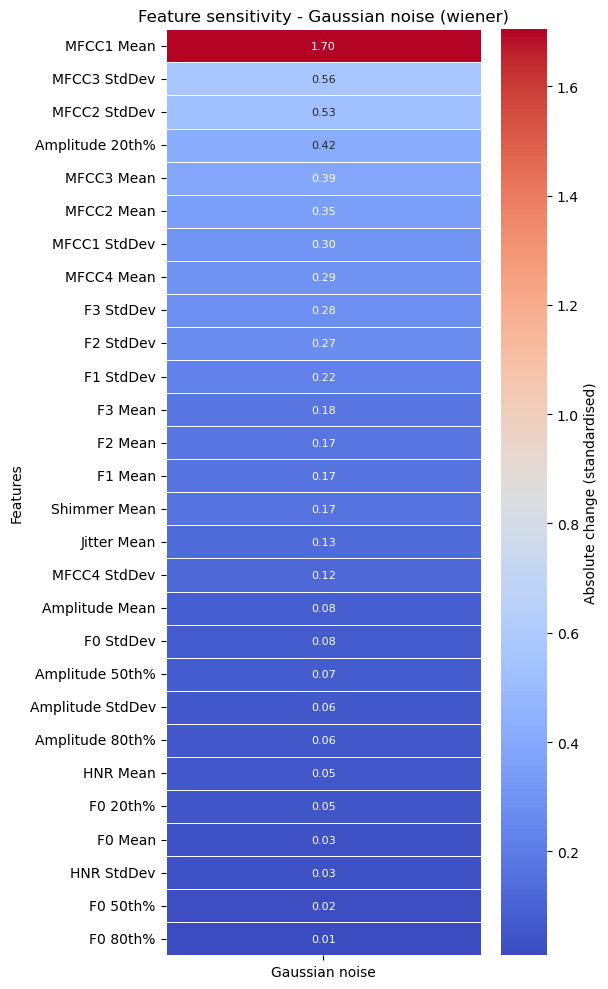

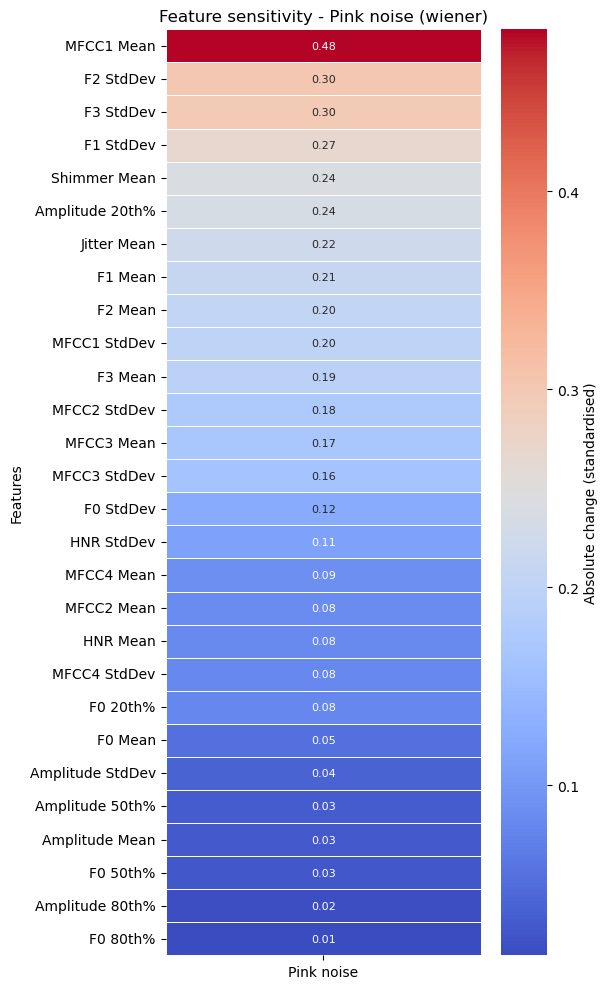

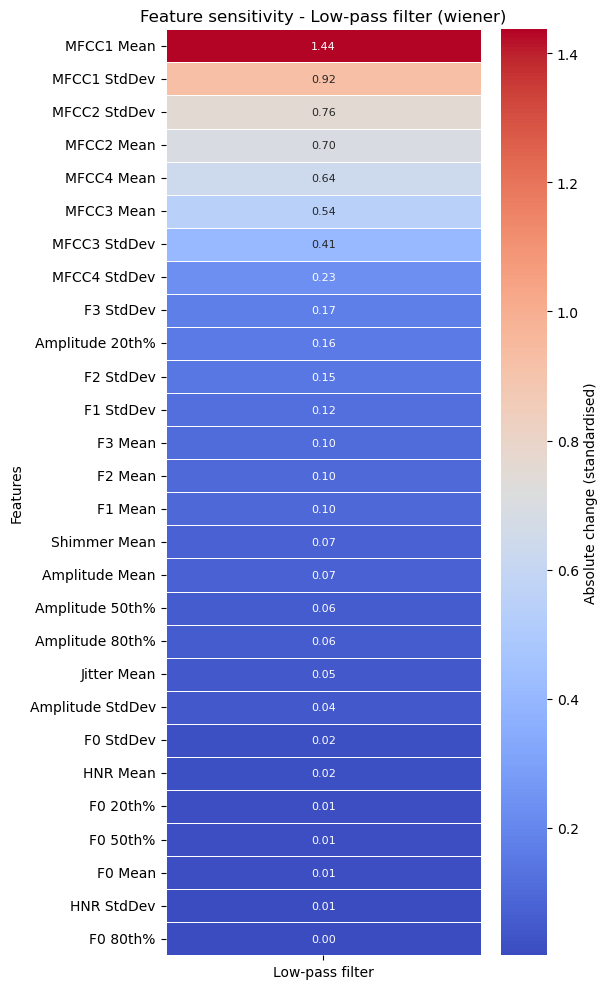

===== Running original =====
Feature sensitivity table saved to: C:\Users\marti\Documents\Technical Medicine Master\Stages TM2\TM2-3\Technische opdracht\feature_sensitivity_table_dataset_based_scaling_original.csv
                  Intensity  Gaussian noise  Pink noise  Low-pass filter
F0 Mean            0.001181        0.037476    0.027834         0.009083
F0 20th%           0.001749        0.045677    0.035049         0.014393
F0 50th%           0.000481        0.014131    0.010857         0.005286
F0 80th%           0.000349        0.011528    0.010034         0.006380
F0 StdDev          0.007007        0.207289    0.154354         0.040693
F1 Mean            0.020105        0.183073    0.147687         0.087356
F1 StdDev          0.027381        0.227760    0.199590         0.110226
F2 Mean            0.022506        0.199276    0.160970         0.088201
F2 StdDev          0.037443        0.318577    0.275042         0.138846
F3 Mean            0.020398        0.234280    0.171934 

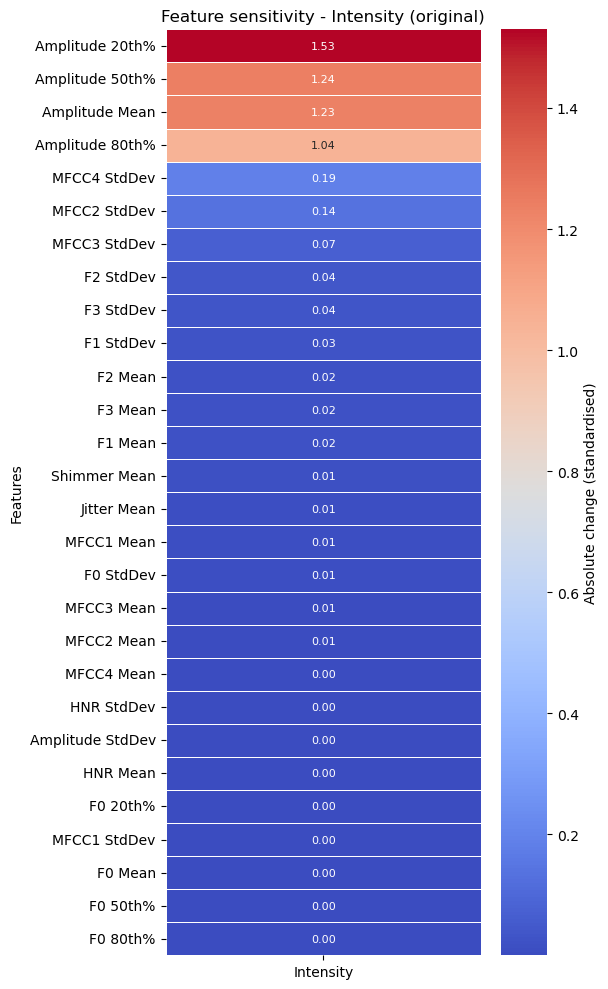

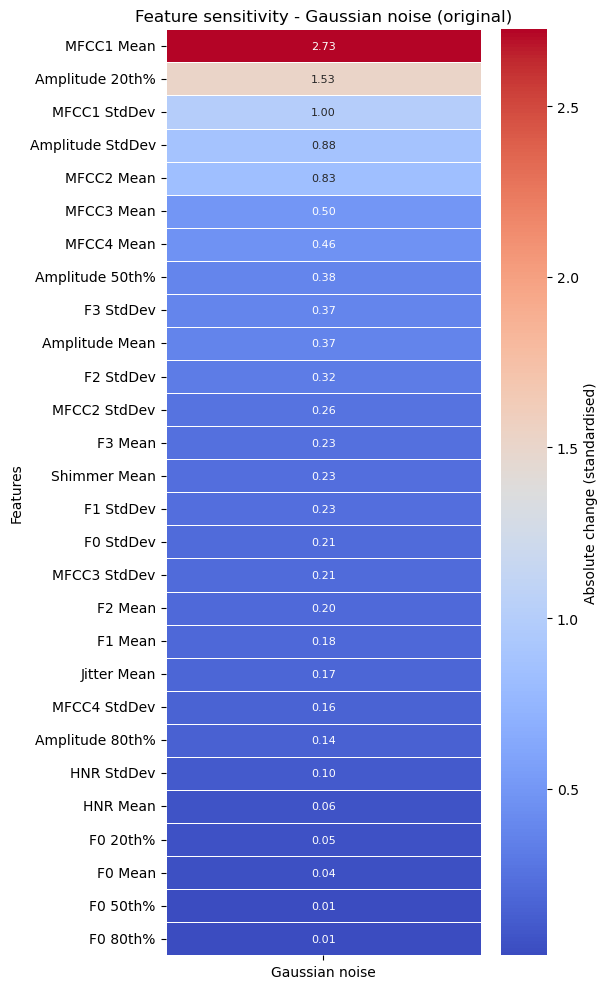

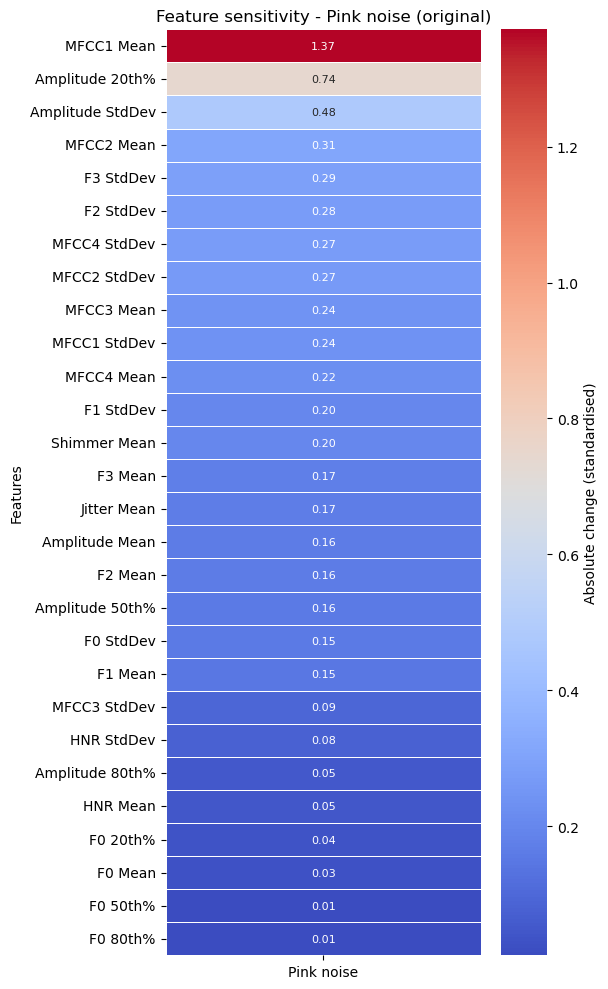

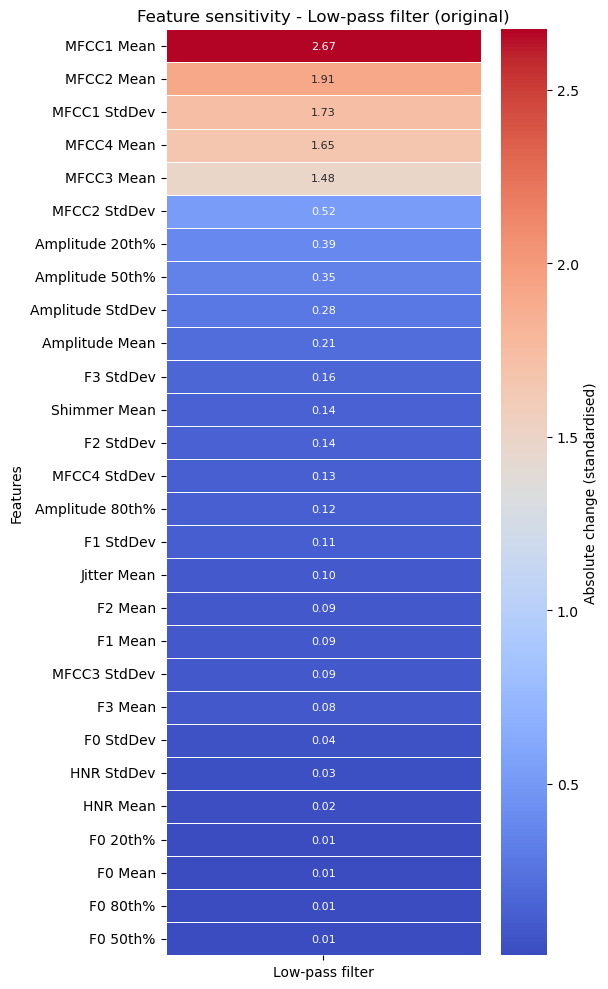

Comparison table saved to: C:\Users\marti\Documents\Technical Medicine Master\Stages TM2\TM2-3\Technische opdracht\feature_sensitivity_comparison_dataset_based_scaling_wiener_minus_original.csv
                  Intensity  Gaussian noise  Pink noise  Low-pass filter
F0 Mean            0.002511       -0.003960    0.025722         0.000025
F0 20th%           0.001534        0.001424    0.043601        -0.001259
F0 50th%           0.002947        0.004889    0.015428         0.006641
F0 80th%           0.000656       -0.001672    0.004079        -0.003705
F0 StdDev          0.001604       -0.131525   -0.030269        -0.022340
F1 Mean            0.023471       -0.016231    0.062618         0.009453
F1 StdDev          0.028509       -0.007341    0.067653         0.009348
F2 Mean            0.020525       -0.026924    0.043380         0.010749
F2 StdDev          0.030584       -0.045188    0.027743         0.008570
F3 Mean            0.023257       -0.059043    0.021442         0.019920
F3 

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler

# =========================
# Paths + settings
# =========================
BASE_PATH = Path(r"C:\Users\marti\Documents\Technical Medicine Master\Stages TM2\TM2-3\Technische opdracht")

RUN_ORIGINAL = True
RUN_WIENER = True

OUTPUT_FILES = {
    "original": BASE_PATH / "feature_sensitivity_table_dataset_based_scaling_original.csv",
    "wiener": BASE_PATH / "feature_sensitivity_table_dataset_based_scaling_wiener.csv",
}

HEATMAP_DIR = BASE_PATH / "heatmaps_per_perturbation_dataset_based_scaling"
HEATMAP_DIR.mkdir(parents=True, exist_ok=True)

SAVE_COMPARISON_TABLE = True
COMPARISON_OUTPUT_FILE = BASE_PATH / "feature_sensitivity_comparison_dataset_based_scaling_wiener_minus_original.csv"

# =========================
# Selected features
# =========================
selected_features = {
    "F0 Mean": "F0semitoneFrom27.5Hz_sma3nz_amean",
    "F0 20th%": "F0semitoneFrom27.5Hz_sma3nz_percentile20.0",
    "F0 50th%": "F0semitoneFrom27.5Hz_sma3nz_percentile50.0",
    "F0 80th%": "F0semitoneFrom27.5Hz_sma3nz_percentile80.0",
    "F0 StdDev": "F0semitoneFrom27.5Hz_sma3nz_stddevNorm",
    "F1 Mean": "F1frequency_sma3nz_amean",
    "F1 StdDev": "F1frequency_sma3nz_stddevNorm",
    "F2 Mean": "F2frequency_sma3nz_amean",
    "F2 StdDev": "F2frequency_sma3nz_stddevNorm",
    "F3 Mean": "F3frequency_sma3nz_amean",
    "F3 StdDev": "F3frequency_sma3nz_stddevNorm",
    "HNR Mean": "HNRdBACF_sma3nz_amean",
    "HNR StdDev": "HNRdBACF_sma3nz_stddevNorm",
    "Jitter Mean": "jitterLocal_sma3nz_amean",
    "Amplitude Mean": "loudness_sma3_amean",
    "Amplitude 20th%": "loudness_sma3_percentile20.0",
    "Amplitude 50th%": "loudness_sma3_percentile50.0",
    "Amplitude 80th%": "loudness_sma3_percentile80.0",
    "Amplitude StdDev": "loudness_sma3_stddevNorm",
    "MFCC1 Mean": "mfcc1_sma3_amean",
    "MFCC1 StdDev": "mfcc1_sma3_stddevNorm",
    "MFCC2 Mean": "mfcc2_sma3_amean",
    "MFCC2 StdDev": "mfcc2_sma3_stddevNorm",
    "MFCC3 Mean": "mfcc3_sma3_amean",
    "MFCC3 StdDev": "mfcc3_sma3_stddevNorm",
    "MFCC4 Mean": "mfcc4_sma3_amean",
    "MFCC4 StdDev": "mfcc4_sma3_stddevNorm",
    "Shimmer Mean": "shimmerLocaldB_sma3nz_amean",
}

# =========================
# Perturbations
# =========================
PERTURBATION_GROUPS = {}

if RUN_WIENER:
    PERTURBATION_GROUPS["wiener"] = {
        "Intensity": {
            "original": BASE_PATH / "opensmile_wiener_pain.csv",
            "-6": BASE_PATH / "opensmile_wiener_intensity_-6dB_pain.csv",
            "-3": BASE_PATH / "opensmile_wiener_intensity_-3dB_pain.csv",
            "+3": BASE_PATH / "opensmile_wiener_intensity_3dB_pain.csv",
            "+6": BASE_PATH / "opensmile_wiener_intensity_6dB_pain.csv",
        },
        "Gaussian noise": {
            "original": BASE_PATH / "opensmile_wiener_pain.csv",
            "0.5": BASE_PATH / "opensmile_wiener_gaussian_low_pain.csv",
            "2": BASE_PATH / "opensmile_wiener_gaussian_medium_pain.csv",
            "5": BASE_PATH / "opensmile_wiener_gaussian_high_pain.csv",
            "10": BASE_PATH / "opensmile_wiener_gaussian_very_high_pain.csv",
        },
        "Pink noise": {
            "original": BASE_PATH / "opensmile_wiener_pain.csv",
            "0.5": BASE_PATH / "opensmile_wiener_pink_low_pain.csv",
            "2": BASE_PATH / "opensmile_wiener_pink_medium_pain.csv",
            "5": BASE_PATH / "opensmile_wiener_pink_high_pain.csv",
            "10": BASE_PATH / "opensmile_wiener_pink_very_high_pain.csv",
        },
        "Low-pass filter": {
            "original": BASE_PATH / "opensmile_wiener_pain.csv",
            "6000": BASE_PATH / "opensmile_wiener_lowpass_low_pain.csv",
            "5000": BASE_PATH / "opensmile_wiener_lowpass_medium_pain.csv",
            "4000": BASE_PATH / "opensmile_wiener_lowpass_high_pain.csv",
            "3000": BASE_PATH / "opensmile_wiener_lowpass_very_high_pain.csv",
        },
    }

if RUN_ORIGINAL:
    PERTURBATION_GROUPS["original"] = {
        "Intensity": {
            "original": BASE_PATH / "opensmile_original_pain.csv",
            "-6": BASE_PATH / "opensmile_original_intensity_-6dB_pain.csv",
            "-3": BASE_PATH / "opensmile_original_intensity_-3dB_pain.csv",
            "+3": BASE_PATH / "opensmile_original_intensity_3dB_pain.csv",
            "+6": BASE_PATH / "opensmile_original_intensity_6dB_pain.csv",
        },
        "Gaussian noise": {
            "original": BASE_PATH / "opensmile_original_pain.csv",
            "0.5": BASE_PATH / "opensmile_original_gaussian_low_pain.csv",
            "2": BASE_PATH / "opensmile_original_gaussian_medium_pain.csv",
            "5": BASE_PATH / "opensmile_original_gaussian_high_pain.csv",
            "10": BASE_PATH / "opensmile_original_gaussian_very_high_pain.csv",
        },
        "Pink noise": {
            "original": BASE_PATH / "opensmile_original_pain.csv",
            "0.5": BASE_PATH / "opensmile_original_pink_low_pain.csv",
            "2": BASE_PATH / "opensmile_original_pink_medium_pain.csv",
            "5": BASE_PATH / "opensmile_original_pink_high_pain.csv",
            "10": BASE_PATH / "opensmile_original_pink_very_high_pain.csv",
        },
        "Low-pass filter": {
            "original": BASE_PATH / "opensmile_original_pain.csv",
            "6000": BASE_PATH / "opensmile_original_lowpass_low_pain.csv",
            "5000": BASE_PATH / "opensmile_original_lowpass_medium_pain.csv",
            "4000": BASE_PATH / "opensmile_original_lowpass_high_pain.csv",
            "3000": BASE_PATH / "opensmile_original_lowpass_very_high_pain.csv",
        },
    }

if not PERTURBATION_GROUPS:
    raise ValueError("Set RUN_ORIGINAL and/or RUN_WIENER to True.")

# =========================
# Functions
# =========================
def load_and_sort_csv(file_path):
    df = pd.read_csv(file_path)
    return df.sort_values(by=["participant_id", "filename"]).reset_index(drop=True)


def check_alignment(reference_df, comparison_df, label):
    ref_ids = reference_df[["participant_id", "filename"]]
    cmp_ids = comparison_df[["participant_id", "filename"]]

    if not ref_ids.equals(cmp_ids):
        raise ValueError(f"Mismatch in rows for {label}")


def fit_dataset_scalers(base_path, feature_cols):
    """
    Fit one scaler on clean original data
    and one scaler on clean wiener data.
    """
    original_clean_path = base_path / "opensmile_original_pain.csv"
    wiener_clean_path = base_path / "opensmile_wiener_pain.csv"

    original_clean_df = load_and_sort_csv(original_clean_path)
    wiener_clean_df = load_and_sort_csv(wiener_clean_path)

    missing_original = [
        col for col in feature_cols if col not in original_clean_df.columns
    ]
    missing_wiener = [
        col for col in feature_cols if col not in wiener_clean_df.columns
    ]

    if missing_original:
        raise ValueError(f"Missing features in original clean CSV: {missing_original}")
    if missing_wiener:
        raise ValueError(f"Missing features in wiener clean CSV: {missing_wiener}")

    original_scaler = StandardScaler()
    original_scaler.fit(original_clean_df[feature_cols])

    wiener_scaler = StandardScaler()
    wiener_scaler.fit(wiener_clean_df[feature_cols])

    return {
        "original": original_scaler,
        "wiener": wiener_scaler,
    }


def run_sensitivity_analysis(dataset_name, perturbation_groups, output_file, dataset_scaler):
    """
    Calculate feature sensitivity per perturbation group for one dataset.

    Scaling is performed per dataset:
    - original data -> scaler fitted on opensmile_original_pain.csv
    - wiener data   -> scaler fitted on opensmile_wiener_pain.csv

    Absolute difference:
    |x'_clean - x'_perturbed|
    """
    all_data = {}

    for group_name, files in perturbation_groups.items():
        all_data[group_name] = {}
        for level_label, file_path in files.items():
            all_data[group_name][level_label] = load_and_sort_csv(file_path)

    for group_name, dfs in all_data.items():
        clean_df = dfs["original"]
        for level_label, df in dfs.items():
            if level_label == "original":
                continue
            check_alignment(clean_df, df, f"{dataset_name} - {group_name} - {level_label}")

    feature_cols = list(selected_features.values())

    for group_name, dfs in all_data.items():
        clean_df = dfs["original"]
        missing_features = [
            col for col in feature_cols if col not in clean_df.columns
        ]
        if missing_features:
            raise ValueError(
                f"These features are missing from the CSV files for {dataset_name} - {group_name}: {missing_features}"
            )

    results = pd.DataFrame(
        index=selected_features.keys(),
        columns=perturbation_groups.keys(),
        dtype=float
    )

    for group_name, dfs in all_data.items():
        clean_df = dfs["original"]
        clean_std = dataset_scaler.transform(clean_df[feature_cols])

        for i, (feature_name, feature_col) in enumerate(selected_features.items()):
            level_scores = []

            for level_label, df in dfs.items():
                if level_label == "original":
                    continue

                perturbed_std = dataset_scaler.transform(df[feature_cols])

                abs_diff = np.abs(clean_std[:, i] - perturbed_std[:, i])
                level_scores.append(abs_diff.mean())

            results.loc[feature_name, group_name] = np.mean(level_scores)

    results.to_csv(output_file)

    print(f"Feature sensitivity table saved to: {output_file}")
    print(results)
    print()

    return results


def save_heatmaps(results_df, dataset_name, heatmap_dir):
    dataset_heatmap_dir = heatmap_dir / dataset_name
    dataset_heatmap_dir.mkdir(parents=True, exist_ok=True)

    for group_name in results_df.columns:
        heatmap_data = results_df[[group_name]].copy()
        heatmap_data = heatmap_data.sort_values(by=group_name, ascending=False)

        plt.figure(figsize=(6, 10))
        sns.heatmap(
            heatmap_data,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            cbar_kws={"label": "Absolute change (standardised)"},
            linewidths=0.5,
            cbar=True,
            annot_kws={"size": 8}
        )

        plt.title(f"Feature sensitivity - {group_name} ({dataset_name})")
        plt.xlabel("")
        plt.ylabel("Features")
        plt.tight_layout()

        plt.savefig(
            dataset_heatmap_dir / f"heatmap_{group_name.replace(' ', '_')}_{dataset_name}.png",
            dpi=300
        )
        plt.show()
        plt.close()


def save_original_vs_wiener_comparison(all_results, output_file):
    if "original" not in all_results or "wiener" not in all_results:
        return

    comparison_df = all_results["wiener"] - all_results["original"]
    comparison_df.to_csv(output_file)

    print(f"Comparison table saved to: {output_file}")
    print(comparison_df)
    print()


# =========================
# Run
# =========================
all_results = {}

print("RUN_ORIGINAL =", RUN_ORIGINAL)
print("RUN_WIENER =", RUN_WIENER)
print()

feature_cols = list(selected_features.values())

# Fit one scaler per dataset
dataset_scalers = fit_dataset_scalers(BASE_PATH, feature_cols)

for dataset_name, perturbation_groups in PERTURBATION_GROUPS.items():
    print(f"===== Running {dataset_name} =====")

    results = run_sensitivity_analysis(
        dataset_name=dataset_name,
        perturbation_groups=perturbation_groups,
        output_file=OUTPUT_FILES[dataset_name],
        dataset_scaler=dataset_scalers[dataset_name]
    )

    all_results[dataset_name] = results
    save_heatmaps(results, dataset_name, HEATMAP_DIR)

if SAVE_COMPARISON_TABLE:
    save_original_vs_wiener_comparison(all_results, COMPARISON_OUTPUT_FILE)

Nu voor absolute difference, standardiseren. En dan nu apart eerst voor original en dan apart voor Wiener

RUN_ORIGINAL = True
RUN_WIENER = True

===== Running wiener =====
Scaled abs-difference table saved to: C:\Users\marti\Documents\Technical Medicine Master\Stages TM2\TM2-3\Technische opdracht\feature_sensitivity_table_absdiff_scaled_wiener.csv
                  Intensity  Gaussian noise  Pink noise  Low-pass filter
F0 Mean           -0.314786        0.126471    0.422963        -0.234649
F0 20th%          -0.146747        0.052583    0.196096        -0.101932
F0 50th%          -0.090136        0.029603    0.085403        -0.024869
F0 80th%          -0.117877        0.058749    0.143671        -0.084543
F0 StdDev         -0.319159        0.126495    0.447173        -0.254509
F1 Mean           -0.485740        0.212051    0.458088        -0.184398
F1 StdDev         -0.458607        0.228015    0.423431        -0.192838
F2 Mean           -0.494909        0.243808    0.426587        -0.175486
F2 StdDev         -0.452382        0.262924    0.365314        -0.175857
F3 Mean           -0.49750

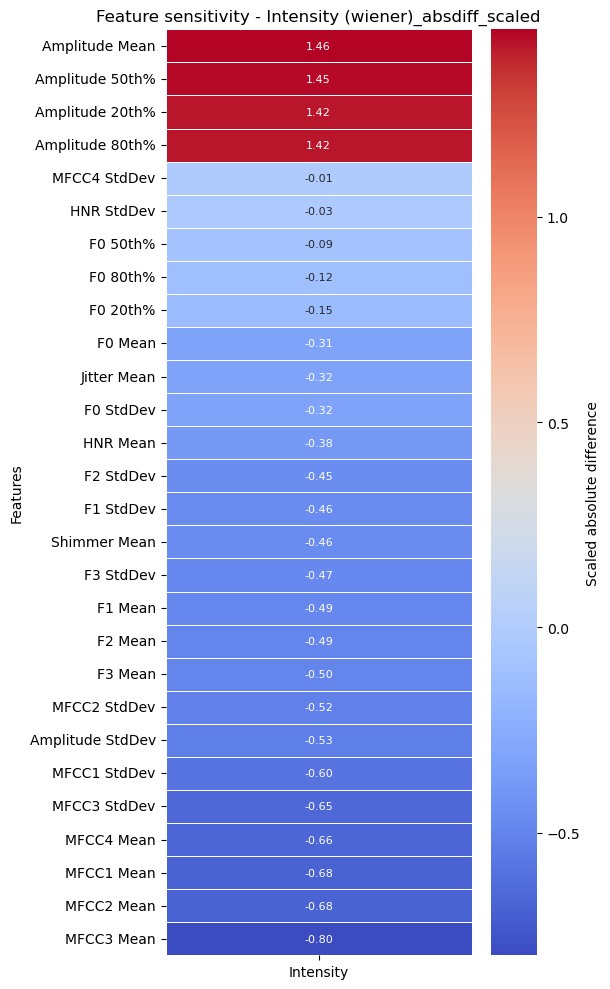

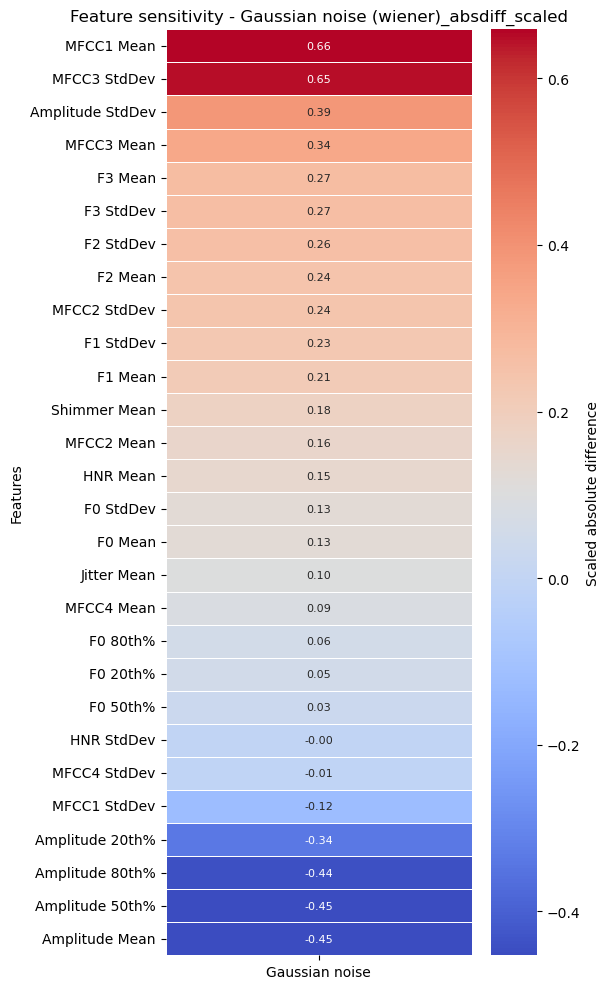

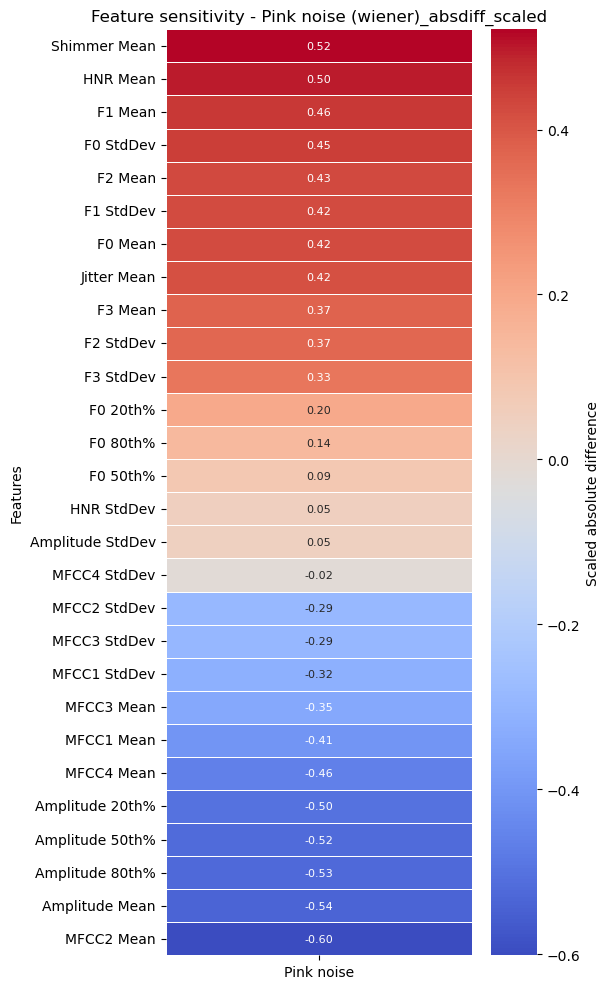

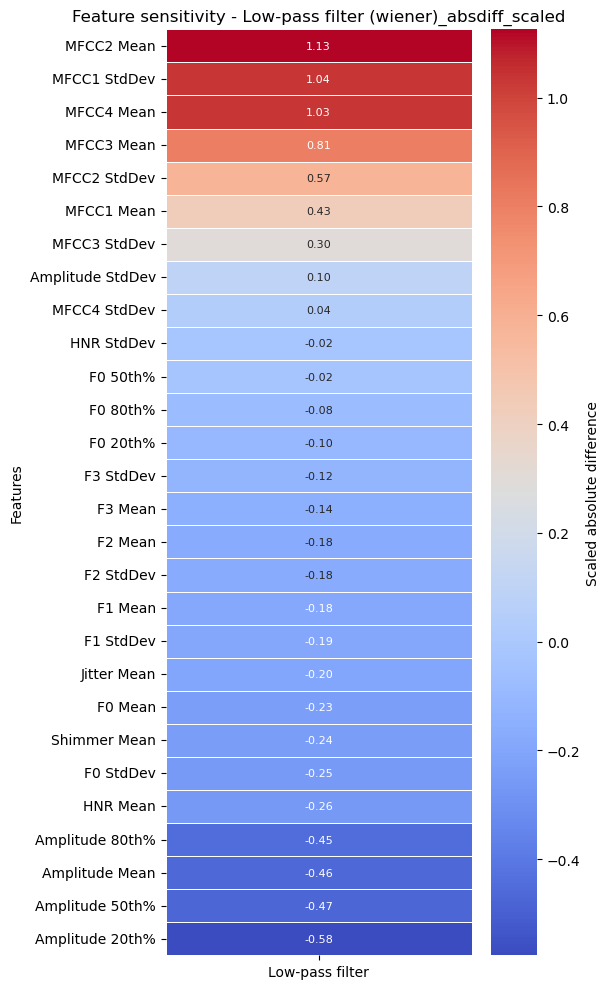

===== Running original =====
Scaled abs-difference table saved to: C:\Users\marti\Documents\Technical Medicine Master\Stages TM2\TM2-3\Technische opdracht\feature_sensitivity_table_absdiff_scaled_original.csv
                  Intensity  Gaussian noise  Pink noise  Low-pass filter
F0 Mean           -0.247941        0.260122    0.125149        -0.137331
F0 20th%          -0.118301        0.112994    0.057032        -0.051725
F0 50th%          -0.133253        0.119100    0.058576        -0.044423
F0 80th%          -0.238823        0.158241    0.105167        -0.024585
F0 StdDev         -0.241392        0.265763    0.131722        -0.156092
F1 Mean           -0.552137        0.453791    0.235371        -0.137025
F1 StdDev         -0.526883        0.400379    0.270022        -0.143518
F2 Mean           -0.551301        0.472024    0.250270        -0.170993
F2 StdDev         -0.544435        0.442827    0.289944        -0.188335
F3 Mean           -0.549380        0.545262    0.226180      

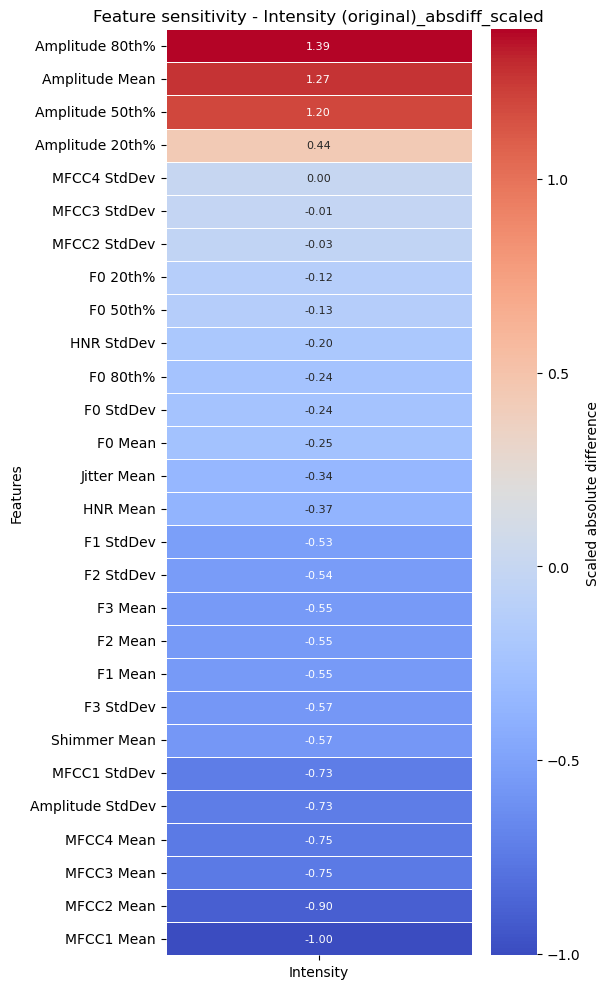

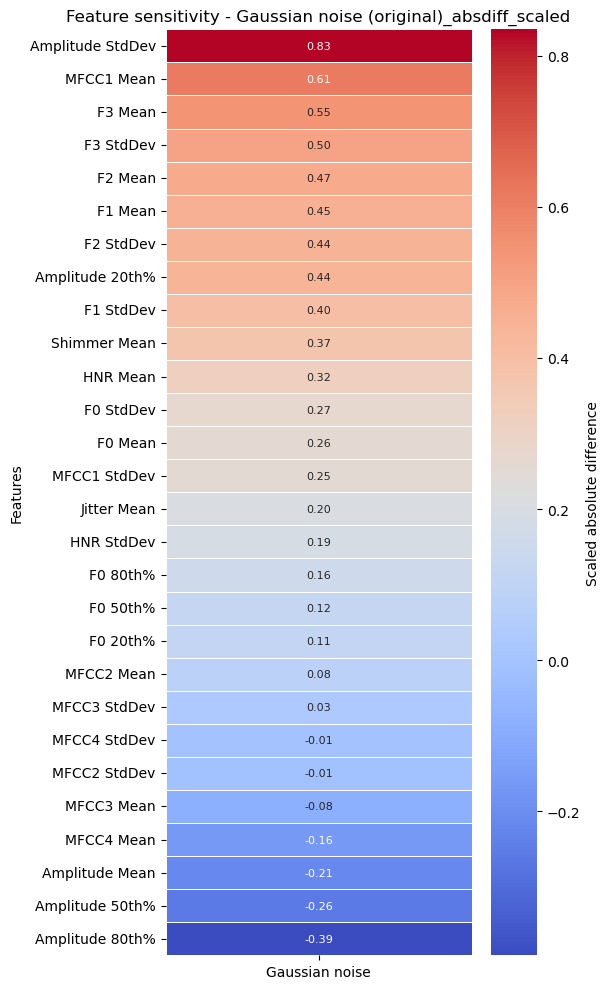

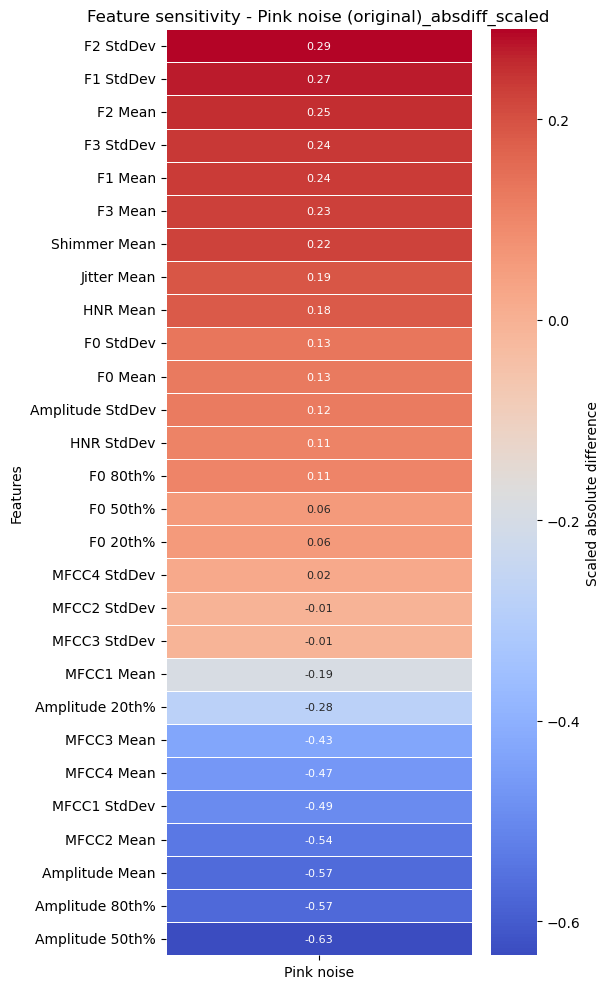

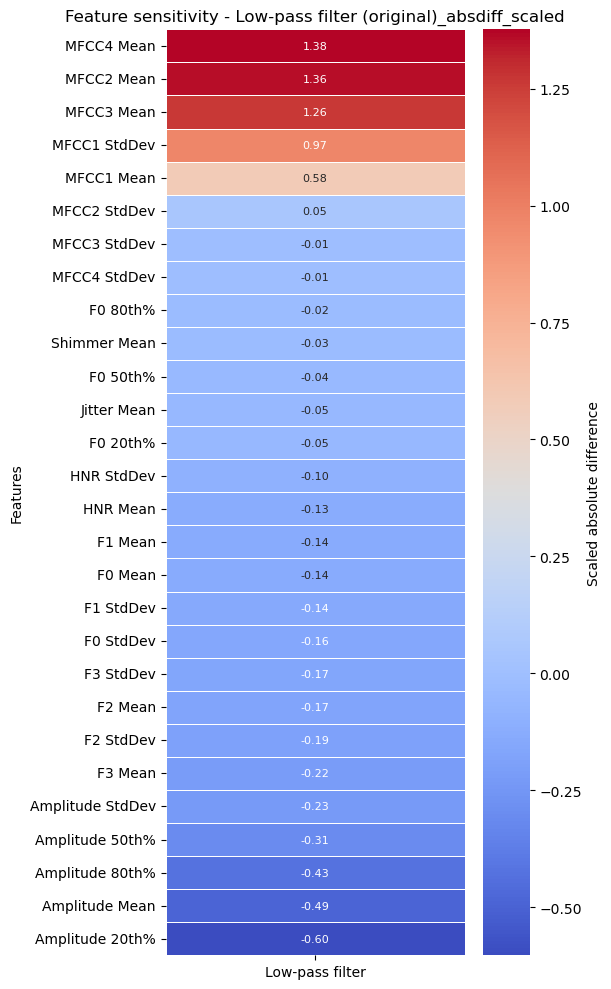

Comparison table saved to: C:\Users\marti\Documents\Technical Medicine Master\Stages TM2\TM2-3\Technische opdracht\feature_sensitivity_comparison_absdiff_scaled_wiener_minus_original.csv
                  Intensity  Gaussian noise  Pink noise  Low-pass filter
F0 Mean           -0.066845       -0.133651    0.297815        -0.097318
F0 20th%          -0.028446       -0.060411    0.139064        -0.050206
F0 50th%           0.043117       -0.089497    0.026827         0.019553
F0 80th%           0.120946       -0.099492    0.038504        -0.059957
F0 StdDev         -0.077767       -0.139269    0.315451        -0.098416
F1 Mean            0.066397       -0.241740    0.222717        -0.047373
F1 StdDev          0.068275       -0.172363    0.153409        -0.049321
F2 Mean            0.056392       -0.228216    0.176317        -0.004493
F2 StdDev          0.092053       -0.179902    0.075370         0.012479
F3 Mean            0.051876       -0.276948    0.147712         0.077360
F3 StdDev 

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler

# =========================
# Paths + settings
# =========================
BASE_PATH = Path(r"C:\Users\marti\Documents\Technical Medicine Master\Stages TM2\TM2-3\Technische opdracht")

RUN_ORIGINAL = True
RUN_WIENER = True

OUTPUT_FILES = {
    "original": BASE_PATH / "feature_sensitivity_table_absdiff_scaled_original.csv",
    "wiener": BASE_PATH / "feature_sensitivity_table_absdiff_scaled_wiener.csv",
}

HEATMAP_DIR = BASE_PATH / "heatmaps_per_perturbation_absdiff_scaled"
HEATMAP_DIR.mkdir(parents=True, exist_ok=True)

SAVE_COMPARISON_TABLE = True
COMPARISON_OUTPUT_FILE = BASE_PATH / "feature_sensitivity_comparison_absdiff_scaled_wiener_minus_original.csv"

# Optional: save raw abs diff summaries too
SAVE_RAW_ABSDIFF_TABLES = True
RAW_OUTPUT_FILES = {
    "original": BASE_PATH / "feature_sensitivity_table_raw_absdiff_original.csv",
    "wiener": BASE_PATH / "feature_sensitivity_table_raw_absdiff_wiener.csv",
}

# =========================
# Selected features
# =========================
selected_features = {
    "F0 Mean": "F0semitoneFrom27.5Hz_sma3nz_amean",
    "F0 20th%": "F0semitoneFrom27.5Hz_sma3nz_percentile20.0",
    "F0 50th%": "F0semitoneFrom27.5Hz_sma3nz_percentile50.0",
    "F0 80th%": "F0semitoneFrom27.5Hz_sma3nz_percentile80.0",
    "F0 StdDev": "F0semitoneFrom27.5Hz_sma3nz_stddevNorm",
    "F1 Mean": "F1frequency_sma3nz_amean",
    "F1 StdDev": "F1frequency_sma3nz_stddevNorm",
    "F2 Mean": "F2frequency_sma3nz_amean",
    "F2 StdDev": "F2frequency_sma3nz_stddevNorm",
    "F3 Mean": "F3frequency_sma3nz_amean",
    "F3 StdDev": "F3frequency_sma3nz_stddevNorm",
    "HNR Mean": "HNRdBACF_sma3nz_amean",
    "HNR StdDev": "HNRdBACF_sma3nz_stddevNorm",
    "Jitter Mean": "jitterLocal_sma3nz_amean",
    "Amplitude Mean": "loudness_sma3_amean",
    "Amplitude 20th%": "loudness_sma3_percentile20.0",
    "Amplitude 50th%": "loudness_sma3_percentile50.0",
    "Amplitude 80th%": "loudness_sma3_percentile80.0",
    "Amplitude StdDev": "loudness_sma3_stddevNorm",
    "MFCC1 Mean": "mfcc1_sma3_amean",
    "MFCC1 StdDev": "mfcc1_sma3_stddevNorm",
    "MFCC2 Mean": "mfcc2_sma3_amean",
    "MFCC2 StdDev": "mfcc2_sma3_stddevNorm",
    "MFCC3 Mean": "mfcc3_sma3_amean",
    "MFCC3 StdDev": "mfcc3_sma3_stddevNorm",
    "MFCC4 Mean": "mfcc4_sma3_amean",
    "MFCC4 StdDev": "mfcc4_sma3_stddevNorm",
    "Shimmer Mean": "shimmerLocaldB_sma3nz_amean",
}

# =========================
# Perturbations
# =========================
PERTURBATION_GROUPS = {}

if RUN_WIENER:
    PERTURBATION_GROUPS["wiener"] = {
        "Intensity": {
            "original": BASE_PATH / "opensmile_wiener_pain.csv",
            "-6": BASE_PATH / "opensmile_wiener_intensity_-6dB_pain.csv",
            "-3": BASE_PATH / "opensmile_wiener_intensity_-3dB_pain.csv",
            "+3": BASE_PATH / "opensmile_wiener_intensity_3dB_pain.csv",
            "+6": BASE_PATH / "opensmile_wiener_intensity_6dB_pain.csv",
        },
        "Gaussian noise": {
            "original": BASE_PATH / "opensmile_wiener_pain.csv",
            "0.5": BASE_PATH / "opensmile_wiener_gaussian_low_pain.csv",
            "2": BASE_PATH / "opensmile_wiener_gaussian_medium_pain.csv",
            "5": BASE_PATH / "opensmile_wiener_gaussian_high_pain.csv",
            "10": BASE_PATH / "opensmile_wiener_gaussian_very_high_pain.csv",
        },
        "Pink noise": {
            "original": BASE_PATH / "opensmile_wiener_pain.csv",
            "0.5": BASE_PATH / "opensmile_wiener_pink_low_pain.csv",
            "2": BASE_PATH / "opensmile_wiener_pink_medium_pain.csv",
            "5": BASE_PATH / "opensmile_wiener_pink_high_pain.csv",
            "10": BASE_PATH / "opensmile_wiener_pink_very_high_pain.csv",
        },
        "Low-pass filter": {
            "original": BASE_PATH / "opensmile_wiener_pain.csv",
            "6000": BASE_PATH / "opensmile_wiener_lowpass_low_pain.csv",
            "5000": BASE_PATH / "opensmile_wiener_lowpass_medium_pain.csv",
            "4000": BASE_PATH / "opensmile_wiener_lowpass_high_pain.csv",
            "3000": BASE_PATH / "opensmile_wiener_lowpass_very_high_pain.csv",
        },
    }

if RUN_ORIGINAL:
    PERTURBATION_GROUPS["original"] = {
        "Intensity": {
            "original": BASE_PATH / "opensmile_original_pain.csv",
            "-6": BASE_PATH / "opensmile_original_intensity_-6dB_pain.csv",
            "-3": BASE_PATH / "opensmile_original_intensity_-3dB_pain.csv",
            "+3": BASE_PATH / "opensmile_original_intensity_3dB_pain.csv",
            "+6": BASE_PATH / "opensmile_original_intensity_6dB_pain.csv",
        },
        "Gaussian noise": {
            "original": BASE_PATH / "opensmile_original_pain.csv",
            "0.5": BASE_PATH / "opensmile_original_gaussian_low_pain.csv",
            "2": BASE_PATH / "opensmile_original_gaussian_medium_pain.csv",
            "5": BASE_PATH / "opensmile_original_gaussian_high_pain.csv",
            "10": BASE_PATH / "opensmile_original_gaussian_very_high_pain.csv",
        },
        "Pink noise": {
            "original": BASE_PATH / "opensmile_original_pain.csv",
            "0.5": BASE_PATH / "opensmile_original_pink_low_pain.csv",
            "2": BASE_PATH / "opensmile_original_pink_medium_pain.csv",
            "5": BASE_PATH / "opensmile_original_pink_high_pain.csv",
            "10": BASE_PATH / "opensmile_original_pink_very_high_pain.csv",
        },
        "Low-pass filter": {
            "original": BASE_PATH / "opensmile_original_pain.csv",
            "6000": BASE_PATH / "opensmile_original_lowpass_low_pain.csv",
            "5000": BASE_PATH / "opensmile_original_lowpass_medium_pain.csv",
            "4000": BASE_PATH / "opensmile_original_lowpass_high_pain.csv",
            "3000": BASE_PATH / "opensmile_original_lowpass_very_high_pain.csv",
        },
    }

if not PERTURBATION_GROUPS:
    raise ValueError("Set RUN_ORIGINAL and/or RUN_WIENER to True.")

# =========================
# Functions
# =========================
def load_and_sort_csv(file_path):
    df = pd.read_csv(file_path)
    return df.sort_values(by=["participant_id", "filename"]).reset_index(drop=True)


def check_alignment(reference_df, comparison_df, label):
    ref_ids = reference_df[["participant_id", "filename"]]
    cmp_ids = comparison_df[["participant_id", "filename"]]
    if not ref_ids.equals(cmp_ids):
        raise ValueError(f"Mismatch in rows for {label}")


def load_all_data(perturbation_groups):
    all_data = {}
    for group_name, files in perturbation_groups.items():
        all_data[group_name] = {}
        for level_label, file_path in files.items():
            all_data[group_name][level_label] = load_and_sort_csv(file_path)
    return all_data


def validate_features_and_alignment(all_data, feature_cols, dataset_name):
    for group_name, dfs in all_data.items():
        clean_df = dfs["original"]

        missing_features = [col for col in feature_cols if col not in clean_df.columns]
        if missing_features:
            raise ValueError(
                f"Missing features in {dataset_name} - {group_name}: {missing_features}"
            )

        for level_label, df in dfs.items():
            if level_label == "original":
                continue
            check_alignment(clean_df, df, f"{dataset_name} - {group_name} - {level_label}")


def collect_all_raw_absdiffs(all_data, feature_cols):
    """
    Collect all raw absolute differences across:
    - all perturbation groups
    - all perturbation levels
    - all files

    Output shape:
    stacked_absdiffs: (total_number_of_rows_over_all_levels, n_features)
    """
    all_absdiff_arrays = []

    for group_name, dfs in all_data.items():
        clean_df = dfs["original"]
        clean_values = clean_df[feature_cols].to_numpy()

        for level_label, df in dfs.items():
            if level_label == "original":
                continue

            perturbed_values = df[feature_cols].to_numpy()
            abs_diff = np.abs(clean_values - perturbed_values)
            all_absdiff_arrays.append(abs_diff)

    stacked_absdiffs = np.vstack(all_absdiff_arrays)
    return stacked_absdiffs


def fit_absdiff_scaler(all_data, feature_cols):
    """
    Fit StandardScaler on ALL raw absolute differences within one dataset.
    """
    stacked_absdiffs = collect_all_raw_absdiffs(all_data, feature_cols)

    scaler = StandardScaler()
    scaler.fit(stacked_absdiffs)
    return scaler


def run_sensitivity_analysis_absdiff_scaled(dataset_name, perturbation_groups, output_file, raw_output_file=None):
    """
    1. Compute raw absolute differences on unscaled feature values
    2. Fit one scaler on ALL raw absolute differences within this dataset
    3. Transform the absolute differences
    4. Average over files per level
    5. Average over levels per perturbation group
    """
    feature_cols = list(selected_features.values())

    all_data = load_all_data(perturbation_groups)
    validate_features_and_alignment(all_data, feature_cols, dataset_name)

    # Fit scaler on all raw absolute differences within this dataset
    absdiff_scaler = fit_absdiff_scaler(all_data, feature_cols)

    results_scaled = pd.DataFrame(
        index=selected_features.keys(),
        columns=perturbation_groups.keys(),
        dtype=float
    )

    results_raw = pd.DataFrame(
        index=selected_features.keys(),
        columns=perturbation_groups.keys(),
        dtype=float
    )

    for group_name, dfs in all_data.items():
        clean_df = dfs["original"]
        clean_values = clean_df[feature_cols].to_numpy()

        for i, (feature_name, feature_col) in enumerate(selected_features.items()):
            raw_level_scores = []
            scaled_level_scores = []

            for level_label, df in dfs.items():
                if level_label == "original":
                    continue

                perturbed_values = df[feature_cols].to_numpy()

                # Step 1: raw absolute difference
                abs_diff_raw = np.abs(clean_values - perturbed_values)

                # Step 2: scale the absolute differences
                abs_diff_scaled = absdiff_scaler.transform(abs_diff_raw)

                raw_level_scores.append(abs_diff_raw[:, i].mean())
                scaled_level_scores.append(abs_diff_scaled[:, i].mean())

            results_raw.loc[feature_name, group_name] = np.mean(raw_level_scores)
            results_scaled.loc[feature_name, group_name] = np.mean(scaled_level_scores)

    results_scaled.to_csv(output_file)
    print(f"Scaled abs-difference table saved to: {output_file}")
    print(results_scaled)
    print()

    if raw_output_file is not None:
        results_raw.to_csv(raw_output_file)
        print(f"Raw abs-difference table saved to: {raw_output_file}")
        print(results_raw)
        print()

    return results_scaled, results_raw


def save_heatmaps(results_df, dataset_name, heatmap_dir, suffix=""):
    dataset_heatmap_dir = heatmap_dir / dataset_name
    dataset_heatmap_dir.mkdir(parents=True, exist_ok=True)

    for group_name in results_df.columns:
        heatmap_data = results_df[[group_name]].copy()
        heatmap_data = heatmap_data.sort_values(by=group_name, ascending=False)

        plt.figure(figsize=(6, 10))
        sns.heatmap(
            heatmap_data,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            cbar_kws={"label": "Scaled absolute difference"},
            linewidths=0.5,
            cbar=True,
            annot_kws={"size": 8}
        )

        plt.title(f"Feature sensitivity - {group_name} ({dataset_name}){suffix}")
        plt.xlabel("")
        plt.ylabel("Features")
        plt.tight_layout()

        filename = f"heatmap_{group_name.replace(' ', '_')}_{dataset_name}{suffix.replace(' ', '_')}.png"
        plt.savefig(dataset_heatmap_dir / filename, dpi=300)
        plt.show()
        plt.close()


def save_original_vs_wiener_comparison(all_results, output_file):
    if "original" not in all_results or "wiener" not in all_results:
        return

    comparison_df = all_results["wiener"] - all_results["original"]
    comparison_df.to_csv(output_file)

    print(f"Comparison table saved to: {output_file}")
    print(comparison_df)
    print()


# =========================
# Run
# =========================
all_results_scaled = {}
all_results_raw = {}

print("RUN_ORIGINAL =", RUN_ORIGINAL)
print("RUN_WIENER =", RUN_WIENER)
print()

for dataset_name, perturbation_groups in PERTURBATION_GROUPS.items():
    print(f"===== Running {dataset_name} =====")

    scaled_results, raw_results = run_sensitivity_analysis_absdiff_scaled(
        dataset_name=dataset_name,
        perturbation_groups=perturbation_groups,
        output_file=OUTPUT_FILES[dataset_name],
        raw_output_file=RAW_OUTPUT_FILES[dataset_name] if SAVE_RAW_ABSDIFF_TABLES else None
    )

    all_results_scaled[dataset_name] = scaled_results
    all_results_raw[dataset_name] = raw_results

    save_heatmaps(scaled_results, dataset_name, HEATMAP_DIR, suffix="_absdiff_scaled")

if SAVE_COMPARISON_TABLE:
    save_original_vs_wiener_comparison(all_results_scaled, COMPARISON_OUTPUT_FILE)

Nu standardisatie met absolute values, original toepassen op alles 

RUN_ORIGINAL = True
RUN_WIENER = True

===== Running wiener =====
Scaled abs-difference table saved to: C:\Users\marti\Documents\Technical Medicine Master\Stages TM2\TM2-3\Technische opdracht\feature_sensitivity_table_absdiff_original_reference_scaled_wiener.csv
                  Intensity  Gaussian noise  Pink noise  Low-pass filter
F0 Mean           -0.215604        0.179200    0.444479        -0.143904
F0 20th%          -0.107029        0.166347    0.363171        -0.045566
F0 50th%          -0.074824        0.231318    0.373985         0.092047
F0 80th%          -0.215297        0.101104    0.253229        -0.155582
F0 StdDev         -0.217219        0.109671    0.344891        -0.169797
F1 Mean           -0.417551        0.314203    0.572215        -0.101542
F1 StdDev         -0.437581        0.198301    0.379275        -0.191452
F2 Mean           -0.456729        0.219049    0.386256        -0.164520
F2 StdDev         -0.461506        0.185787    0.278441        -0.211273
F3 Mean

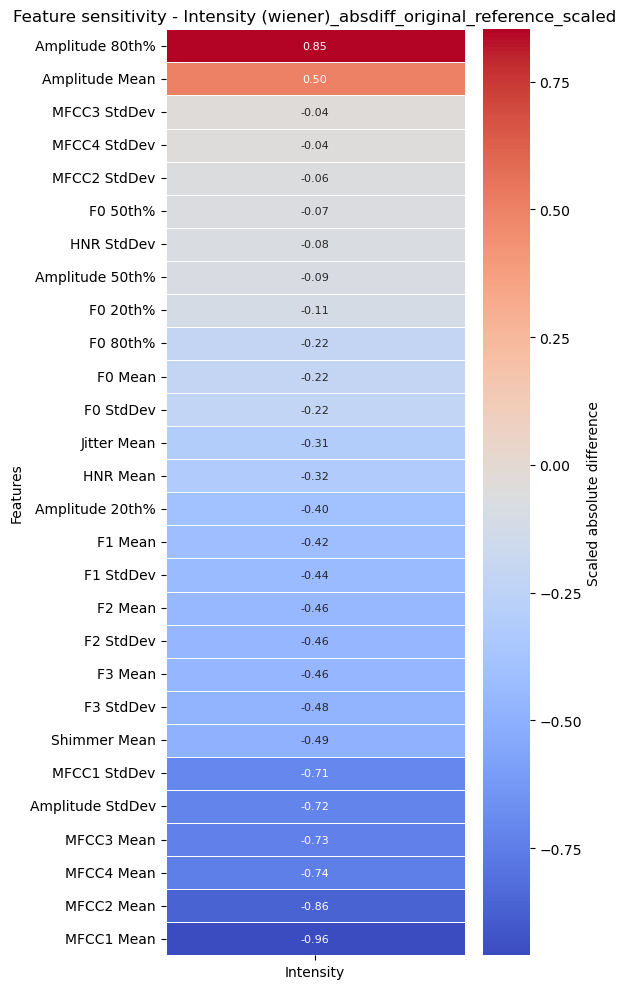

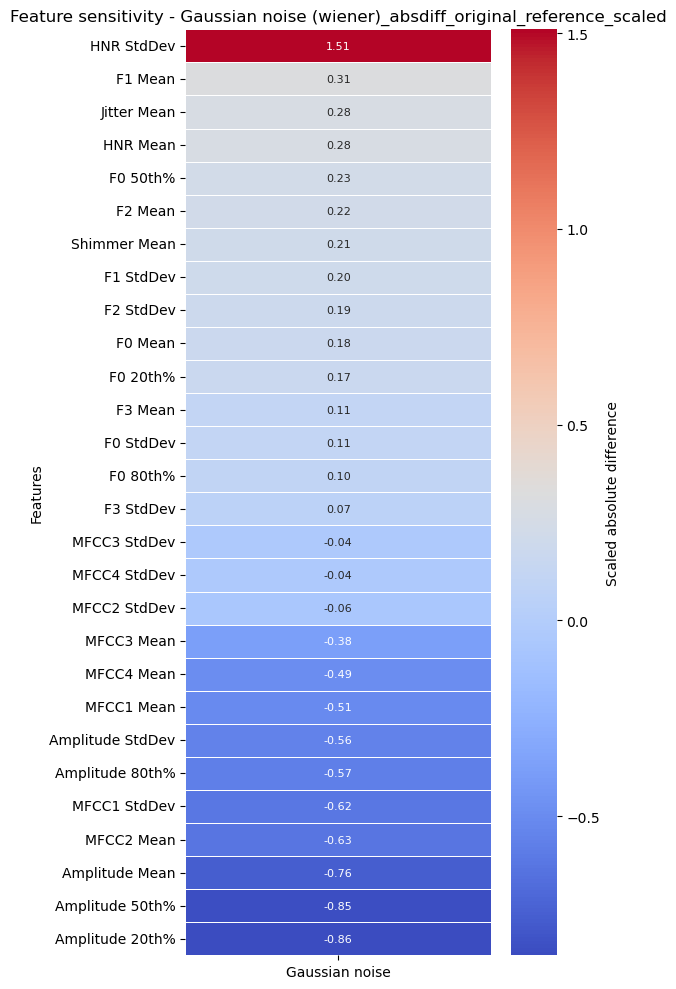

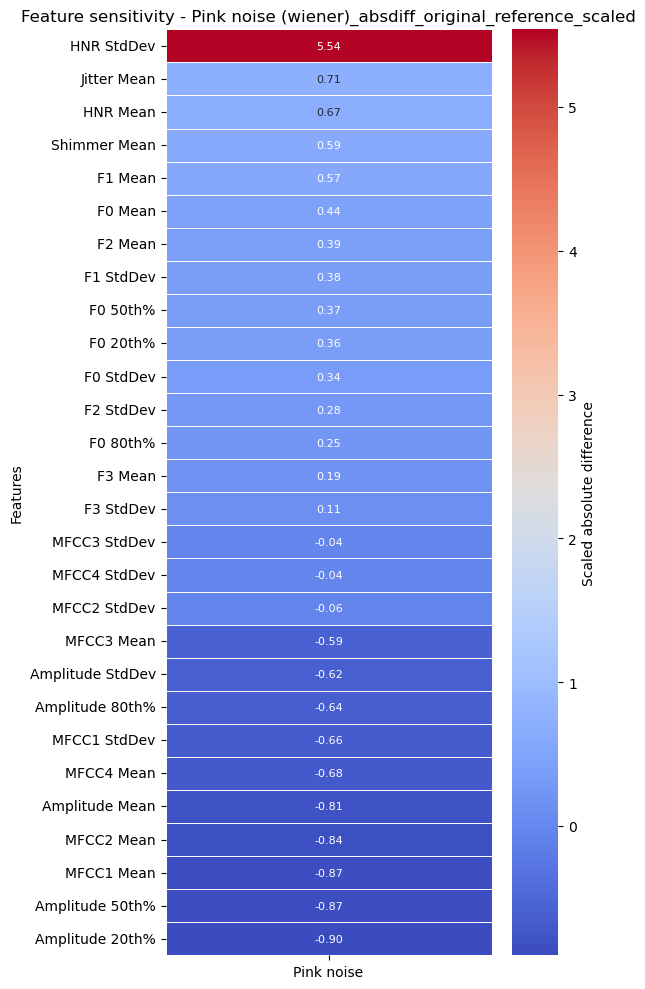

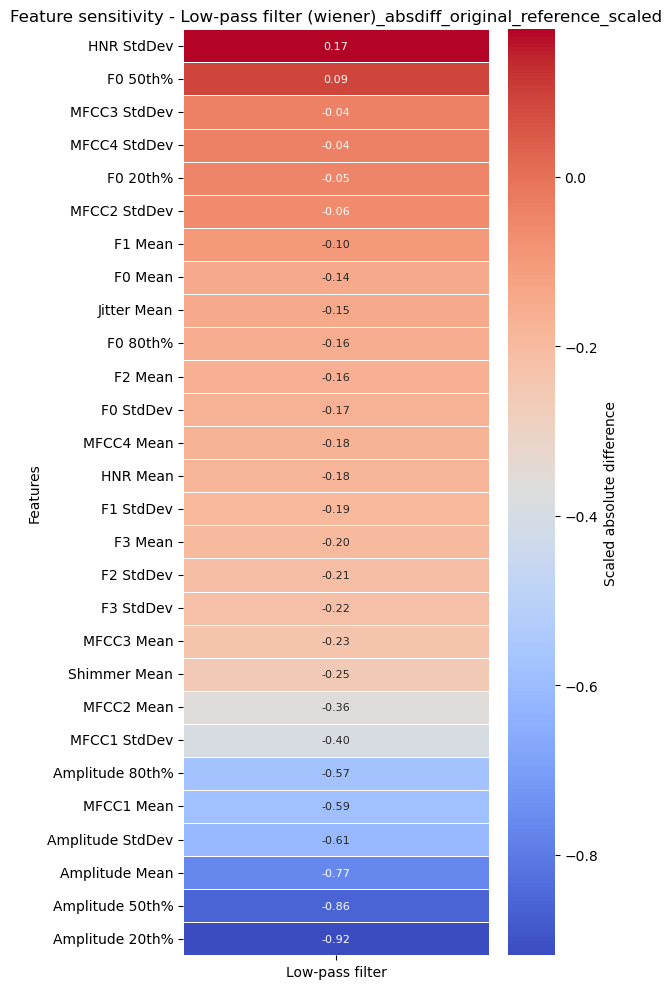

===== Running original =====
Scaled abs-difference table saved to: C:\Users\marti\Documents\Technical Medicine Master\Stages TM2\TM2-3\Technische opdracht\feature_sensitivity_table_absdiff_original_reference_scaled_original.csv
                  Intensity  Gaussian noise  Pink noise  Low-pass filter
F0 Mean           -0.247941        0.260122    0.125149        -0.137331
F0 20th%          -0.118301        0.112994    0.057032        -0.051725
F0 50th%          -0.133253        0.119100    0.058576        -0.044423
F0 80th%          -0.238823        0.158241    0.105167        -0.024585
F0 StdDev         -0.241392        0.265763    0.131722        -0.156092
F1 Mean           -0.552137        0.453791    0.235371        -0.137025
F1 StdDev         -0.526883        0.400379    0.270022        -0.143518
F2 Mean           -0.551301        0.472024    0.250270        -0.170993
F2 StdDev         -0.544435        0.442827    0.289944        -0.188335
F3 Mean           -0.549380        0.54526

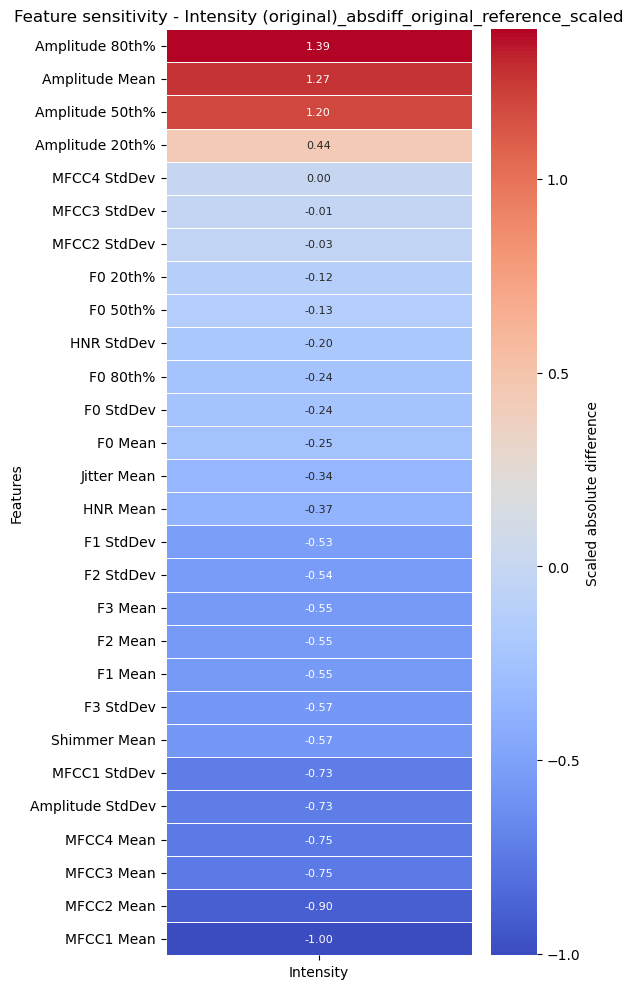

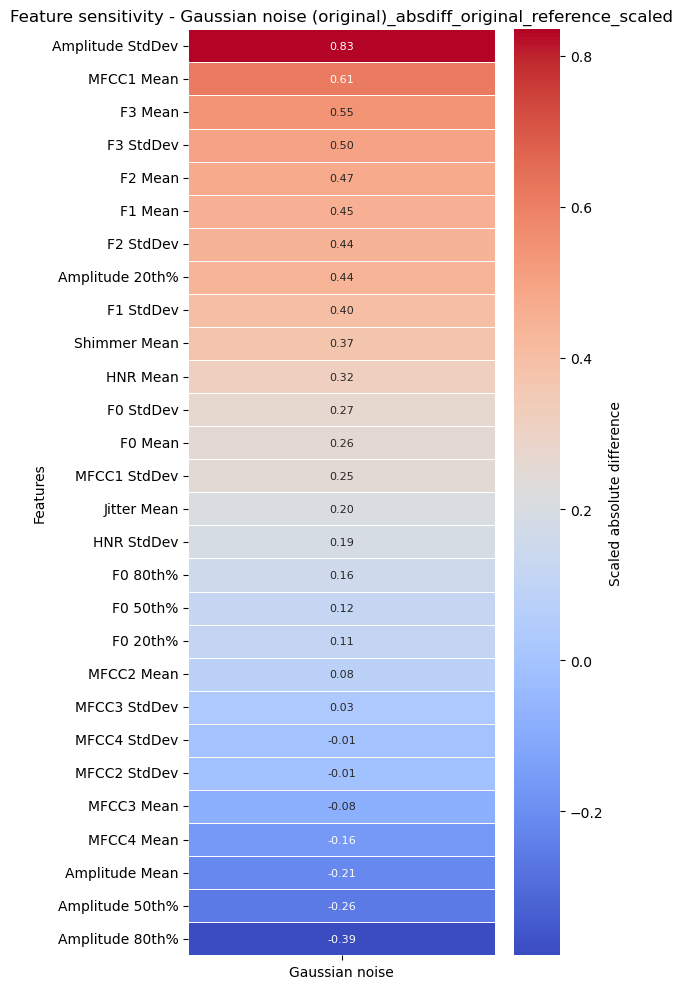

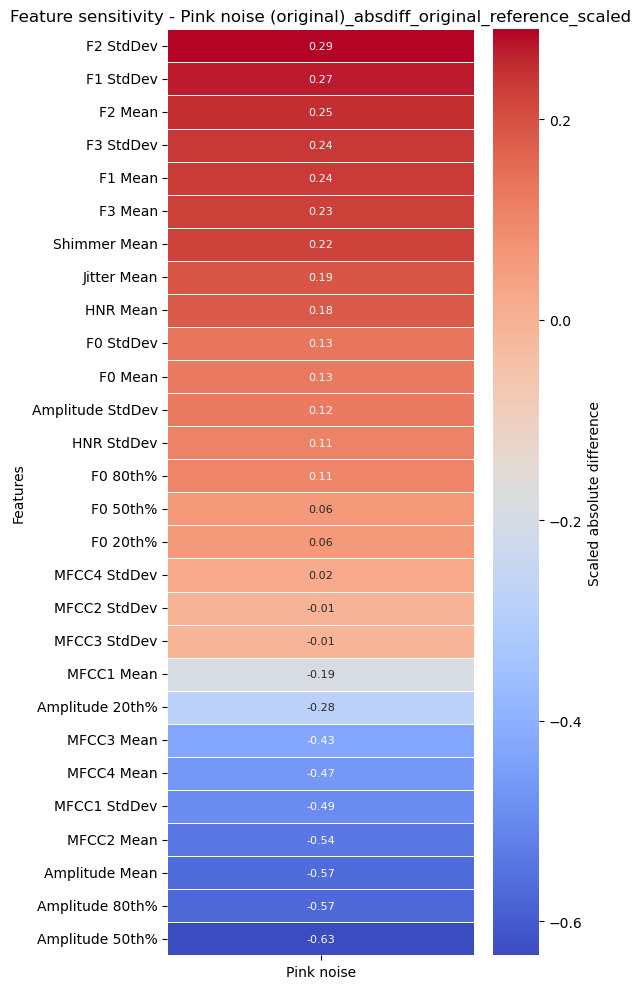

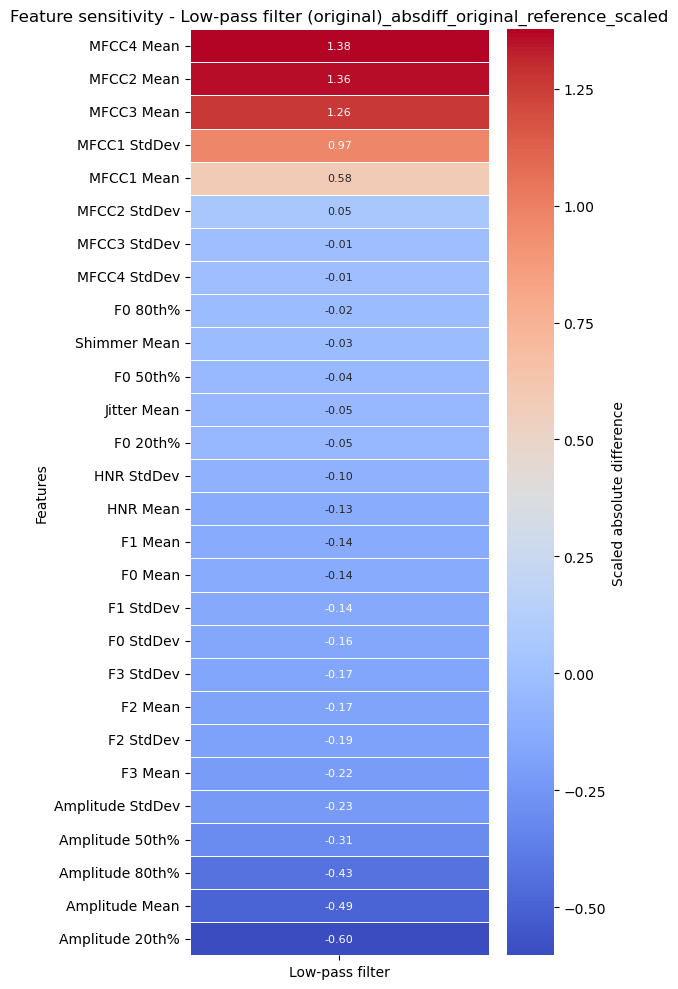

Comparison table saved to: C:\Users\marti\Documents\Technical Medicine Master\Stages TM2\TM2-3\Technische opdracht\feature_sensitivity_comparison_absdiff_original_reference_scaled_wiener_minus_original.csv
                  Intensity  Gaussian noise  Pink noise  Low-pass filter
F0 Mean            0.032336       -0.080923    0.319330        -0.006573
F0 20th%           0.011272        0.053354    0.306139         0.006160
F0 50th%           0.058429        0.112218    0.315409         0.136470
F0 80th%           0.023526       -0.057137    0.148062        -0.130997
F0 StdDev          0.024174       -0.156092    0.213170        -0.013705
F1 Mean            0.134586       -0.139588    0.336844         0.035483
F1 StdDev          0.089302       -0.202078    0.109253        -0.047934
F2 Mean            0.094572       -0.252974    0.135986         0.006473
F2 StdDev          0.082930       -0.257040   -0.011503        -0.022938
F3 Mean            0.086032       -0.434631   -0.036418         

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler

# =========================
# Paths + settings
# =========================
BASE_PATH = Path(r"C:\Users\marti\Documents\Technical Medicine Master\Stages TM2\TM2-3\Technische opdracht")

RUN_ORIGINAL = True
RUN_WIENER = True

OUTPUT_FILES = {
    "original": BASE_PATH / "feature_sensitivity_table_absdiff_original_reference_scaled_original.csv",
    "wiener": BASE_PATH / "feature_sensitivity_table_absdiff_original_reference_scaled_wiener.csv",
}

RAW_OUTPUT_FILES = {
    "original": BASE_PATH / "feature_sensitivity_table_raw_absdiff_original.csv",
    "wiener": BASE_PATH / "feature_sensitivity_table_raw_absdiff_wiener.csv",
}

HEATMAP_DIR = BASE_PATH / "heatmaps_per_perturbation_absdiff_original_reference_scaled"
HEATMAP_DIR.mkdir(parents=True, exist_ok=True)

SAVE_COMPARISON_TABLE = True
COMPARISON_OUTPUT_FILE = BASE_PATH / "feature_sensitivity_comparison_absdiff_original_reference_scaled_wiener_minus_original.csv"

# =========================
# Selected features
# =========================
selected_features = {
    "F0 Mean": "F0semitoneFrom27.5Hz_sma3nz_amean",
    "F0 20th%": "F0semitoneFrom27.5Hz_sma3nz_percentile20.0",
    "F0 50th%": "F0semitoneFrom27.5Hz_sma3nz_percentile50.0",
    "F0 80th%": "F0semitoneFrom27.5Hz_sma3nz_percentile80.0",
    "F0 StdDev": "F0semitoneFrom27.5Hz_sma3nz_stddevNorm",
    "F1 Mean": "F1frequency_sma3nz_amean",
    "F1 StdDev": "F1frequency_sma3nz_stddevNorm",
    "F2 Mean": "F2frequency_sma3nz_amean",
    "F2 StdDev": "F2frequency_sma3nz_stddevNorm",
    "F3 Mean": "F3frequency_sma3nz_amean",
    "F3 StdDev": "F3frequency_sma3nz_stddevNorm",
    "HNR Mean": "HNRdBACF_sma3nz_amean",
    "HNR StdDev": "HNRdBACF_sma3nz_stddevNorm",
    "Jitter Mean": "jitterLocal_sma3nz_amean",
    "Amplitude Mean": "loudness_sma3_amean",
    "Amplitude 20th%": "loudness_sma3_percentile20.0",
    "Amplitude 50th%": "loudness_sma3_percentile50.0",
    "Amplitude 80th%": "loudness_sma3_percentile80.0",
    "Amplitude StdDev": "loudness_sma3_stddevNorm",
    "MFCC1 Mean": "mfcc1_sma3_amean",
    "MFCC1 StdDev": "mfcc1_sma3_stddevNorm",
    "MFCC2 Mean": "mfcc2_sma3_amean",
    "MFCC2 StdDev": "mfcc2_sma3_stddevNorm",
    "MFCC3 Mean": "mfcc3_sma3_amean",
    "MFCC3 StdDev": "mfcc3_sma3_stddevNorm",
    "MFCC4 Mean": "mfcc4_sma3_amean",
    "MFCC4 StdDev": "mfcc4_sma3_stddevNorm",
    "Shimmer Mean": "shimmerLocaldB_sma3nz_amean",
}

# =========================
# Perturbations
# =========================
PERTURBATION_GROUPS = {}

if RUN_WIENER:
    PERTURBATION_GROUPS["wiener"] = {
        "Intensity": {
            "original": BASE_PATH / "opensmile_wiener_pain.csv",
            "-6": BASE_PATH / "opensmile_wiener_intensity_-6dB_pain.csv",
            "-3": BASE_PATH / "opensmile_wiener_intensity_-3dB_pain.csv",
            "+3": BASE_PATH / "opensmile_wiener_intensity_3dB_pain.csv",
            "+6": BASE_PATH / "opensmile_wiener_intensity_6dB_pain.csv",
        },
        "Gaussian noise": {
            "original": BASE_PATH / "opensmile_wiener_pain.csv",
            "0.5": BASE_PATH / "opensmile_wiener_gaussian_low_pain.csv",
            "2": BASE_PATH / "opensmile_wiener_gaussian_medium_pain.csv",
            "5": BASE_PATH / "opensmile_wiener_gaussian_high_pain.csv",
            "10": BASE_PATH / "opensmile_wiener_gaussian_very_high_pain.csv",
        },
        "Pink noise": {
            "original": BASE_PATH / "opensmile_wiener_pain.csv",
            "0.5": BASE_PATH / "opensmile_wiener_pink_low_pain.csv",
            "2": BASE_PATH / "opensmile_wiener_pink_medium_pain.csv",
            "5": BASE_PATH / "opensmile_wiener_pink_high_pain.csv",
            "10": BASE_PATH / "opensmile_wiener_pink_very_high_pain.csv",
        },
        "Low-pass filter": {
            "original": BASE_PATH / "opensmile_wiener_pain.csv",
            "6000": BASE_PATH / "opensmile_wiener_lowpass_low_pain.csv",
            "5000": BASE_PATH / "opensmile_wiener_lowpass_medium_pain.csv",
            "4000": BASE_PATH / "opensmile_wiener_lowpass_high_pain.csv",
            "3000": BASE_PATH / "opensmile_wiener_lowpass_very_high_pain.csv",
        },
    }

if RUN_ORIGINAL:
    PERTURBATION_GROUPS["original"] = {
        "Intensity": {
            "original": BASE_PATH / "opensmile_original_pain.csv",
            "-6": BASE_PATH / "opensmile_original_intensity_-6dB_pain.csv",
            "-3": BASE_PATH / "opensmile_original_intensity_-3dB_pain.csv",
            "+3": BASE_PATH / "opensmile_original_intensity_3dB_pain.csv",
            "+6": BASE_PATH / "opensmile_original_intensity_6dB_pain.csv",
        },
        "Gaussian noise": {
            "original": BASE_PATH / "opensmile_original_pain.csv",
            "0.5": BASE_PATH / "opensmile_original_gaussian_low_pain.csv",
            "2": BASE_PATH / "opensmile_original_gaussian_medium_pain.csv",
            "5": BASE_PATH / "opensmile_original_gaussian_high_pain.csv",
            "10": BASE_PATH / "opensmile_original_gaussian_very_high_pain.csv",
        },
        "Pink noise": {
            "original": BASE_PATH / "opensmile_original_pain.csv",
            "0.5": BASE_PATH / "opensmile_original_pink_low_pain.csv",
            "2": BASE_PATH / "opensmile_original_pink_medium_pain.csv",
            "5": BASE_PATH / "opensmile_original_pink_high_pain.csv",
            "10": BASE_PATH / "opensmile_original_pink_very_high_pain.csv",
        },
        "Low-pass filter": {
            "original": BASE_PATH / "opensmile_original_pain.csv",
            "6000": BASE_PATH / "opensmile_original_lowpass_low_pain.csv",
            "5000": BASE_PATH / "opensmile_original_lowpass_medium_pain.csv",
            "4000": BASE_PATH / "opensmile_original_lowpass_high_pain.csv",
            "3000": BASE_PATH / "opensmile_original_lowpass_very_high_pain.csv",
        },
    }

if not PERTURBATION_GROUPS:
    raise ValueError("Set RUN_ORIGINAL and/or RUN_WIENER to True.")

# =========================
# Functions
# =========================
def load_and_sort_csv(file_path):
    df = pd.read_csv(file_path)
    return df.sort_values(by=["participant_id", "filename"]).reset_index(drop=True)


def check_alignment(reference_df, comparison_df, label):
    ref_ids = reference_df[["participant_id", "filename"]]
    cmp_ids = comparison_df[["participant_id", "filename"]]

    if not ref_ids.equals(cmp_ids):
        raise ValueError(f"Mismatch in rows for {label}")


def load_all_data(perturbation_groups):
    all_data = {}
    for group_name, files in perturbation_groups.items():
        all_data[group_name] = {}
        for level_label, file_path in files.items():
            all_data[group_name][level_label] = load_and_sort_csv(file_path)
    return all_data


def validate_features_and_alignment(all_data, feature_cols, dataset_name):
    for group_name, dfs in all_data.items():
        clean_df = dfs["original"]

        missing_features = [col for col in feature_cols if col not in clean_df.columns]
        if missing_features:
            raise ValueError(
                f"Missing features in {dataset_name} - {group_name}: {missing_features}"
            )

        for level_label, df in dfs.items():
            if level_label == "original":
                continue
            check_alignment(clean_df, df, f"{dataset_name} - {group_name} - {level_label}")


def collect_all_raw_absdiffs(all_data, feature_cols):
    """
    Verzamel alle ruwe absolute differences binnen één dataset.
    Output shape: (n_total_rows_over_all_levels, n_features)
    """
    all_absdiff_arrays = []

    for group_name, dfs in all_data.items():
        clean_values = dfs["original"][feature_cols].to_numpy()

        for level_label, df in dfs.items():
            if level_label == "original":
                continue

            perturbed_values = df[feature_cols].to_numpy()
            abs_diff = np.abs(clean_values - perturbed_values)
            all_absdiff_arrays.append(abs_diff)

    return np.vstack(all_absdiff_arrays)


def fit_original_absdiff_scaler(original_perturbation_groups, feature_cols):
    """
    Fit één scaler op ALLE raw absolute differences van Original.
    Die scaler wordt later gebruikt voor zowel Original als Wiener.
    """
    original_all_data = load_all_data(original_perturbation_groups)
    validate_features_and_alignment(original_all_data, feature_cols, "original")

    stacked_original_absdiffs = collect_all_raw_absdiffs(original_all_data, feature_cols)

    scaler = StandardScaler()
    scaler.fit(stacked_original_absdiffs)
    return scaler


def run_sensitivity_analysis_absdiff_original_reference(
    dataset_name,
    perturbation_groups,
    output_file,
    raw_output_file,
    reference_absdiff_scaler
):
    """
    1. Bereken raw absolute differences op ongeschaalde features
    2. Gebruik één scaler die ALLEEN is gefit op Original absolute differences
    3. Pas die scaler toe op zowel Original als Wiener absolute differences
    4. Bereken gemiddelde score per feature per perturbation group
    """
    feature_cols = list(selected_features.values())

    all_data = load_all_data(perturbation_groups)
    validate_features_and_alignment(all_data, feature_cols, dataset_name)

    results_scaled = pd.DataFrame(
        index=selected_features.keys(),
        columns=perturbation_groups.keys(),
        dtype=float
    )

    results_raw = pd.DataFrame(
        index=selected_features.keys(),
        columns=perturbation_groups.keys(),
        dtype=float
    )

    for group_name, dfs in all_data.items():
        clean_values = dfs["original"][feature_cols].to_numpy()

        for i, (feature_name, feature_col) in enumerate(selected_features.items()):
            raw_level_scores = []
            scaled_level_scores = []

            for level_label, df in dfs.items():
                if level_label == "original":
                    continue

                perturbed_values = df[feature_cols].to_numpy()

                # Ruwe absolute difference
                abs_diff_raw = np.abs(clean_values - perturbed_values)

                # Schalen met scaler die alleen op Original absdiffs is gefit
                abs_diff_scaled = reference_absdiff_scaler.transform(abs_diff_raw)

                raw_level_scores.append(abs_diff_raw[:, i].mean())
                scaled_level_scores.append(abs_diff_scaled[:, i].mean())

            results_raw.loc[feature_name, group_name] = np.mean(raw_level_scores)
            results_scaled.loc[feature_name, group_name] = np.mean(scaled_level_scores)

    results_scaled.to_csv(output_file)
    results_raw.to_csv(raw_output_file)

    print(f"Scaled abs-difference table saved to: {output_file}")
    print(results_scaled)
    print()

    print(f"Raw abs-difference table saved to: {raw_output_file}")
    print(results_raw)
    print()

    return results_scaled, results_raw


def save_heatmaps(results_df, dataset_name, heatmap_dir, suffix=""):
    dataset_heatmap_dir = heatmap_dir / dataset_name
    dataset_heatmap_dir.mkdir(parents=True, exist_ok=True)

    for group_name in results_df.columns:
        heatmap_data = results_df[[group_name]].copy()
        heatmap_data = heatmap_data.sort_values(by=group_name, ascending=False)

        plt.figure(figsize=(6, 10))
        sns.heatmap(
            heatmap_data,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            cbar_kws={"label": "Scaled absolute difference"},
            linewidths=0.5,
            cbar=True,
            annot_kws={"size": 8}
        )

        plt.title(f"Feature sensitivity - {group_name} ({dataset_name}){suffix}")
        plt.xlabel("")
        plt.ylabel("Features")
        plt.tight_layout()

        filename = f"heatmap_{group_name.replace(' ', '_')}_{dataset_name}{suffix.replace(' ', '_')}.png"
        plt.savefig(dataset_heatmap_dir / filename, dpi=300)
        plt.show()
        plt.close()


def save_original_vs_wiener_comparison(all_results, output_file):
    if "original" not in all_results or "wiener" not in all_results:
        return

    comparison_df = all_results["wiener"] - all_results["original"]
    comparison_df.to_csv(output_file)

    print(f"Comparison table saved to: {output_file}")
    print(comparison_df)
    print()


# =========================
# Run
# =========================
all_results_scaled = {}
all_results_raw = {}

print("RUN_ORIGINAL =", RUN_ORIGINAL)
print("RUN_WIENER =", RUN_WIENER)
print()

feature_cols = list(selected_features.values())

# ÉÉN scaler, gefit op alle absolute differences van Original
original_reference_absdiff_scaler = fit_original_absdiff_scaler(
    original_perturbation_groups=PERTURBATION_GROUPS["original"],
    feature_cols=feature_cols
)

for dataset_name, perturbation_groups in PERTURBATION_GROUPS.items():
    print(f"===== Running {dataset_name} =====")

    scaled_results, raw_results = run_sensitivity_analysis_absdiff_original_reference(
        dataset_name=dataset_name,
        perturbation_groups=perturbation_groups,
        output_file=OUTPUT_FILES[dataset_name],
        raw_output_file=RAW_OUTPUT_FILES[dataset_name],
        reference_absdiff_scaler=original_reference_absdiff_scaler
    )

    all_results_scaled[dataset_name] = scaled_results
    all_results_raw[dataset_name] = raw_results

    save_heatmaps(
        results_df=scaled_results,
        dataset_name=dataset_name,
        heatmap_dir=HEATMAP_DIR,
        suffix="_absdiff_original_reference_scaled"
    )

if SAVE_COMPARISON_TABLE:
    save_original_vs_wiener_comparison(all_results_scaled, COMPARISON_OUTPUT_FILE)